In [ ]:
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import sys
from collections import defaultdict
sys.path.append('../')
from utils.prompt_registry import DATASETS, DatasetTaskSpec
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import plotly.express as px
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

# Label Distributions

## Ground Truth Label Distribution

In [459]:
for dataset in DATASETS.keys():
    data_folder = 'sarc' if dataset == 'sarcasm' else dataset
    path = f'../data/{data_folder}/{dataset}.csv'

    df = pd.read_csv(path)
    print(dataset)
    print(df.shape[0])

    print(df['label'].value_counts(normalize=True))


sarcasm
137454
label
sarcastic    0.517286
literal      0.482714
Name: proportion, dtype: float64
sentiment
91964
label
positive    0.538798
negative    0.461202
Name: proportion, dtype: float64
commonsense
9264
label
yes    0.5
no     0.5
Name: proportion, dtype: float64


## First round: Label Distribution
We load in the label consistency of each model's first round predictions. 

In [460]:
for dataset in DATASETS.keys():
    consistency = pd.read_csv(f'../evaluation/{dataset}/main/claims_label_consistency.csv', index_col=0)
    
    total = consistency[['all_negative', 'all_positive', 'mixed']].sum(axis=1)
    consistency['all_negative_rate'] = (consistency['all_negative'] / total) * 100
    consistency['all_positive_rate'] = (consistency['all_positive'] / total) * 100 
    consistency['mixed_rate']        = (consistency['mixed'] / total) * 100 
    
    print(f'\n=== {dataset} ===')
    print(consistency[['model', 'all_negative_rate', 'all_positive_rate', 'mixed_rate']].round(2))


=== sarcasm ===
           model  all_negative_rate  all_positive_rate  mixed_rate
0    gemma-3-27b               6.33              91.61        2.05
1     gemma-3-4b               3.25              95.88        0.87
2    gpt-oss-20b              23.13              18.78       58.09
3   llama-3.1-8b               0.29              85.51       14.21
4  llama-3.3-70b              19.20              73.31        7.50
5   qwen-2.5-72b              12.83              82.12        5.05
6    qwen-2.5-7b               1.39              98.17        0.44

=== sentiment ===
           model  all_negative_rate  all_positive_rate  mixed_rate
0    gemma-3-27b              52.36              46.19        1.45
1     gemma-3-4b              56.30              42.38        1.32
2    gpt-oss-20b              46.13              37.55       16.32
3   llama-3.1-8b              42.85              48.18        8.98
4  llama-3.3-70b              47.53              51.03        1.44
5   qwen-2.5-72b          

Helper function, to drop the version marker of the model names. Used throughout entire notebook.

In [461]:
def simplify_model_name(series: pd.Series) -> pd.Series:
    """
    Dropping version in model names. 
    """
    name = series.str.split('-')
    n_parts = name.str.len()
    
    result = np.where(
        n_parts > 3,
        name.str[0] + '-' + name.str[-3] + '-' + name.str[-2] + '-' + name.str[-1],
        name.str[0] + '-' + name.str[-1]
    )
    return pd.Series(result, index=series.index)

The code below builds a latex table of the main results.

In [462]:
ROW_ORDER = ['gemma-27b', 'gemma-4b', 'llama-70b', 'llama-8b', 'qwen-72b', 'qwen-7b', 'gpt-20b']

def build_consistency_latex(dataset_dfs: dict[str, pd.DataFrame]) -> str:
    """
    dataset_dfs: dict mapping dataset name -> consistency df with rate columns already computed.
    Produces a LaTeX table matching the report style.
    """
    # Index each df by model for easy lookup
    indexed = {ds: df.set_index('model') for ds, df in dataset_dfs.items()}

    rows = []
    for model in ROW_ORDER:
        display = f'\\texttt{{{model}}}'
        cells = []
        for ds, df in indexed.items():
            row = df.loc[model]
            neg  = f'{row["all_negative_rate"]:.1f}'
            pos  = f'{row["all_positive_rate"]:.1f}'
            mix  = f'{row["mixed_rate"]:.1f}'
            cells.append(f'{neg} & {pos} & {mix}')
        rows.append(f'    {display} & ' + ' & '.join(cells) + ' \\\\')

    body = '\n'.join(rows)

    latex = r"""\begin{tabular}{l ccc ccc ccc}
\toprule
\multirow{2}{*}{\textsc{Model}}
& \multicolumn{3}{c}{\textsc{Sarcasm}}
& \multicolumn{3}{c}{\textsc{Sentiment}}
& \multicolumn{3}{c}{\textsc{Commonsense}} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-7} \cmidrule(lr){8-10}
& \tiny All Neg. & \tiny All Pos. & \tiny Mixed
& \tiny All Neg. & \tiny All Pos. & \tiny Mixed
& \tiny All Neg. & \tiny All Pos. & \tiny Mixed \\
\midrule
""" + body + r"""
\bottomrule
\end{tabular}"""

    return latex


# --- collect dfs ---
dataset_dfs = {}
for dataset in DATASETS.keys():
    consistency = pd.read_csv(f'../evaluation/{dataset}/main/claims_label_consistency.csv', index_col=0)
    consistency['model'] = simplify_model_name(consistency['model'])


    total = consistency[['all_negative', 'all_positive', 'mixed']].sum(axis=1)
    consistency['all_negative_rate'] = consistency['all_negative'] / total * 100
    consistency['all_positive_rate'] = consistency['all_positive'] / total * 100
    consistency['mixed_rate']        = consistency['mixed'] / total * 100
    dataset_dfs[dataset] = consistency

print(build_consistency_latex(dataset_dfs))

\begin{tabular}{l ccc ccc ccc}
\toprule
\multirow{2}{*}{\textsc{Model}}
& \multicolumn{3}{c}{\textsc{Sarcasm}}
& \multicolumn{3}{c}{\textsc{Sentiment}}
& \multicolumn{3}{c}{\textsc{Commonsense}} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-7} \cmidrule(lr){8-10}
& \tiny All Neg. & \tiny All Pos. & \tiny Mixed
& \tiny All Neg. & \tiny All Pos. & \tiny Mixed
& \tiny All Neg. & \tiny All Pos. & \tiny Mixed \\
\midrule
    \texttt{gemma-27b} & 6.3 & 91.6 & 2.1 & 52.4 & 46.2 & 1.5 & 49.5 & 47.9 & 2.6 \\
    \texttt{gemma-4b} & 3.2 & 95.9 & 0.9 & 56.3 & 42.4 & 1.3 & 58.0 & 36.7 & 5.3 \\
    \texttt{llama-70b} & 19.2 & 73.3 & 7.5 & 47.5 & 51.0 & 1.4 & 53.5 & 43.0 & 3.4 \\
    \texttt{llama-8b} & 0.3 & 85.5 & 14.2 & 42.8 & 48.2 & 9.0 & 13.2 & 43.3 & 43.5 \\
    \texttt{qwen-72b} & 12.8 & 82.1 & 5.0 & 52.7 & 45.6 & 1.7 & 56.3 & 38.9 & 4.8 \\
    \texttt{qwen-7b} & 1.4 & 98.2 & 0.4 & 49.9 & 48.2 & 1.9 & 77.6 & 19.2 & 3.2 \\
    \texttt{gpt-20b} & 23.1 & 18.8 & 58.1 & 46.1 & 37.6 & 16.3 & 45.1 & 19.1 & 

# Load Influence Scores from Main Experiment

Below, we load the influence scores from the main experiment in three different aggregations: 
1. On an instance level (name: deltas)
2. On a match type level (name: match_type)
3. Aggregated by match type, in order to get a model-level score (name: model)

We do this for both the negative and positive influence scores, and for the agreeing and disagreeing cases.

In [463]:
BASE_PATH = Path('../evaluation')

def load_deltas_main(base_path: Path):
    deltas = defaultdict(lambda: defaultdict(dict))

    for dataset_dir in base_path.iterdir():
        if not dataset_dir.is_dir():
            continue
        
        dataset = dataset_dir / 'main'

        for file in dataset.glob('*.csv'):
            if file.stem == 'claims_label_consistency':
                continue

            name = file.stem

            parts = name.split("_")

            agreement = parts[-1]

            if len(parts) == 2:
                agg = 'all'
            else:
                agg = '_'.join(parts[1:-1])

            df = pd.read_csv(file)

            df['model_sender'] = simplify_model_name(df['model_sender'])
            df['model_receiver'] = simplify_model_name(df['model_receiver'])
            
            deltas[dataset_dir.name][agreement][agg] = df

    return deltas

In [464]:
DELTAS = load_deltas_main(BASE_PATH)

In [465]:
print(DELTAS['sarcasm']['disagreeing']['model'].head(5))

  model_receiver model_sender  macro_pos_delta_realisation  \
0      gemma-27b    gemma-27b                     0.974592   
1      gemma-27b     gemma-4b                     0.804919   
2      gemma-27b      gpt-20b                     0.891568   
3      gemma-27b    llama-70b                     0.815922   
4      gemma-27b     qwen-72b                     0.882615   

   macro_neg_delta_realisation  count  
0                    -0.005032   5644  
1                    -0.026107  12148  
2                    -0.005178  19601  
3                    -0.039557  18155  
4                    -0.016742  17885  


# Plots for Main Experiment

Below, we plots all the results in a heatmap format.

In [466]:
LARGE_MODELS = ['llama-70b','gemma-27b', 'qwen-72b', 'gpt-20b']

ROW_ORDER = sorted(LARGE_MODELS)
COL_ORDER = sorted(LARGE_MODELS)

DATASET_NAMES = ['sarcasm', 'commonsense', 'sentiment'] 

Helpers

In [467]:
def to_pivot(df, value_col, row_order, col_order):
    ''' Pivot long-format df.'''
    pivot = df.pivot(index='model_sender', columns='model_receiver', values=value_col)
    pivot = pivot.reindex(index=row_order, columns=col_order)
    return pivot

In [468]:
def add_marginals(pivot):
    pivot = pivot.copy()
    pivot.loc[:, 'Mean'] = pivot.mean(axis=1)       # marginal column
    pivot.loc['Mean', :] = pivot.mean(axis=0)        # marginal row
    pivot.loc['Mean', 'Mean'] = float('nan')         # exclude corner
    return pivot

In [469]:
def draw_heatmap(ax, pivot, show_ylabel, show_cbar, cbar_ax, pos_delta: bool):
    n_rows, n_cols = pivot.shape
    is_marginal = np.zeros((n_rows, n_cols), dtype=bool)
    bold_marginal = np.zeros((n_rows, n_cols), dtype=bool)

    if 'Mean' in pivot.index:
        is_marginal[pivot.index.get_loc('Mean'), :] = True
    
        mean_col_idx = pivot.columns.get_loc('Mean')
        col_vals = pivot.iloc[:, mean_col_idx].drop('Mean', errors='ignore')
        if pos_delta:
            bold_row = col_vals.idxmax()
        else:
            bold_row = col_vals.idxmin()        
        bold_marginal[pivot.index.get_loc(bold_row), mean_col_idx] = True

        
    if 'Mean' in pivot.columns:
        is_marginal[:, pivot.columns.get_loc('Mean')] = True

        mean_row_idx = pivot.index.get_loc('Mean')
        row_vals = pivot.iloc[mean_row_idx, :].drop('Mean', errors='ignore')
        if pos_delta:
            bold_row = row_vals.idxmax()
        else:
            bold_row = row_vals.idxmin()        

        bold_marginal[mean_row_idx, pivot.columns.get_loc(bold_row)] = True

    sns.heatmap(
        pivot,
        ax=ax,
        cmap=CMAP,
        vmin=VMIN,
        vmax=VMAX,
        mask=is_marginal,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        cbar=show_cbar,
        cbar_ax=cbar_ax,
        square=True,
        cbar_kws={"shrink": 0.2} if show_cbar else {},
        annot_kws={'size': 12}
    )

    ax.patch.set_facecolor('white')
    # manually annotating the marginals
    for r in range(n_rows):
        for c in range(n_cols):
            if is_marginal[r, c]:
                val = pivot.iloc[r, c]
                if not np.isnan(val):
                    ax.text(
                        c + 0.5, r + 0.5,
                        f"{val:.2f}",
                        ha='center', va='center',
                        fontsize=12, color='black',
                        fontweight = 'bold' if bold_marginal[r, c] else 'normal'
                    )
    # Removes title for the mean row/column 
    ax.set_xticklabels([lbl if lbl.get_text() != 'Mean' else '' 
                    for lbl in ax.get_xticklabels()])
    ax.set_yticklabels([lbl if lbl.get_text() != 'Mean' else '' 
                    for lbl in ax.get_yticklabels()])   
    
    # Sets the ylabel and xlabel + puts the xlabel on top 
    ax.set_ylabel("Peer" if show_ylabel else "", fontsize=14, labelpad=15)
    
    ax.xaxis.tick_top()
    plt.setp(ax.get_xticklabels(), rotation=45, ha='left', va='bottom', rotation_mode='default', fontfamily='monospace')
    plt.setp(ax.get_yticklabels(),fontfamily='monospace')
    ax.set_xlabel("Receiver", fontsize=14, labelpad=15)
    ax.xaxis.set_label_position('top')
    ax.tick_params(axis="both", labelsize=12)

    ax.yaxis.label.set_position((0, 0.65))   
    ax.xaxis.label.set_position((0.4, 0))

    # Removes ylabel when it is not on the left most column 
    if not show_ylabel:
        ax.yaxis.set_major_locator(plt.NullLocator())
        ax.set_yticklabels([])
        ax.set_ylabel("")

    # removing ticks from the marginals 
    mean_row_idx = list(pivot.index).index('Mean') if 'Mean' in pivot.index else None
    mean_col_idx = list(pivot.columns).index('Mean') if 'Mean' in pivot.columns else None

    yticks = ax.yaxis.get_major_ticks()
    if mean_row_idx is not None and mean_row_idx < len(yticks):
        yticks[mean_row_idx].tick1line.set_visible(False)

    xticks = ax.xaxis.get_major_ticks()
    if mean_col_idx is not None and mean_col_idx < len(xticks):
        xticks[mean_col_idx].tick2line.set_visible(False)


### Heatmap overall influence, large models

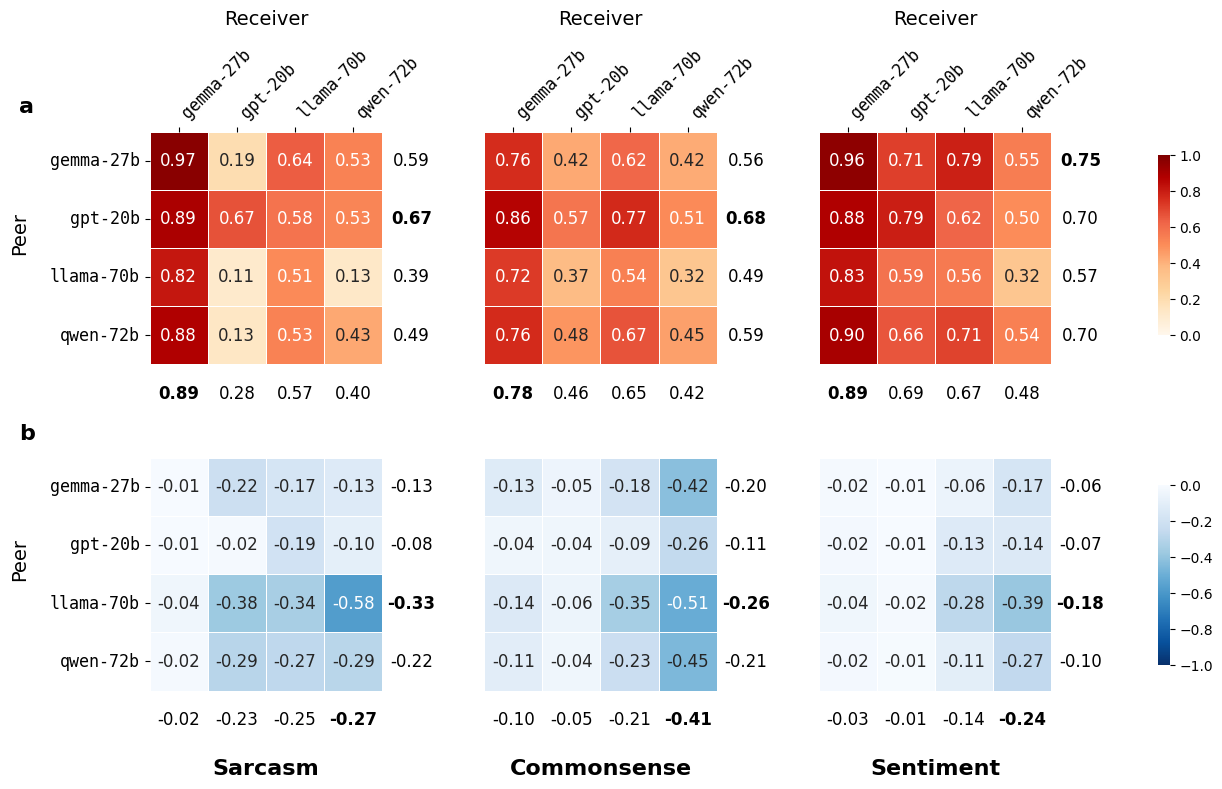

In [470]:
def plot_combined_results(DELTAS):
    fig = plt.figure(figsize=(12, 10))

    grid = gridspec.GridSpec(
        2, 3,
        figure=fig,
        hspace=-0.40,
        wspace=0.15,
        left=0.12,
        right=0.92,
        top=0.92,
        bottom=0.05,
    )

    cbar_ax_pos = fig.add_axes([0.96, 0.59, 0.010, 0.18])
    cbar_ax_neg = fig.add_axes([0.96, 0.26, 0.010, 0.18])

    row_configs = [
        {
            'value_col':  'macro_pos_delta_realisation',
            'pos_delta':  True,
            'cmap':       'OrRd',
            'vmin':        0.0,
            'vmax':        1.0,
            'cbar_ax':    cbar_ax_pos,
            'show_title': False,   
            'show_xticks': True,
            'row_label':  'a',
        },
        {
            'value_col':  'macro_neg_delta_realisation',
            'pos_delta':  False,
            'cmap':       'Blues_r',
            'vmin':       -1.0,
            'vmax':        0.0,
            'cbar_ax':    cbar_ax_neg,
            'show_title': True,  
            'show_xticks': False, 
            'row_label':  'b',
        },
    ]

    for row_idx, cfg in enumerate(row_configs):
        global CMAP, VMIN, VMAX
        CMAP = cfg['cmap']
        VMIN = cfg['vmin']
        VMAX = cfg['vmax']

        cbar_drawn = False
        for col_idx, dataset in enumerate(DATASET_NAMES):

            ax = fig.add_subplot(grid[row_idx, col_idx])
            df_model = DELTAS[dataset]['disagreeing']['model'].copy()
            pivot    = add_marginals(to_pivot(df_model, cfg['value_col'], ROW_ORDER, COL_ORDER))

            show_ylabel = (col_idx == 0)
            show_cbar   = not cbar_drawn

            draw_heatmap(
                ax, pivot,
                show_ylabel=show_ylabel,
                show_cbar=show_cbar,
                cbar_ax=cfg['cbar_ax'] if show_cbar else None,
                pos_delta=cfg['pos_delta'],
            )

            if show_cbar:
                cbar_drawn = True

            if cfg['show_title']:
                ax.set_title(
                    dataset.capitalize(),
                    fontweight='bold', fontsize=16,
                    pad=2, x=0.4, y = -0.1
                )

            if not cfg['show_xticks']:
                ax.xaxis.set_major_locator(plt.NullLocator())
                ax.set_xticklabels([])
                ax.set_xlabel("")

            if col_idx == 0:
                ax.text(
                    -0.45, 1.05, f"{cfg['row_label']}",
                    transform=ax.transAxes,
                    fontsize=16, fontweight='bold',
                    va='bottom', ha='left',
                )
    fig.subplots_adjust(hspace=0.0)

plot_combined_results(DELTAS)
plt.savefig("../plots/combined-overall.png", dpi=300, bbox_inches="tight")
plt.show()

### Heatmap overall influence, intra-family

In [471]:
def plot_main_results_pairs(DELTAS, value_col):

    fig = plt.figure(figsize=(10, 8))
 
    grid = gridspec.GridSpec(
        3, 3,
        figure=fig,
        hspace=0.15, # rows closer together 
        wspace=0.65,
        left=0.14, 
        right=0.92,
        top=0.90, # more space below titles 
        bottom=0.08,
    )
 
    cbar_ax = fig.add_axes([0.96, 0.40, 0.013, 0.30])
 
    cbar_drawn = False

    for row_idx, dataset in enumerate(DATASET_NAMES):
        df_model = DELTAS[dataset]['disagreeing']['model'].copy()

        for col_idx, (m1, m2) in enumerate(PAIRS):
            ax = fig.add_subplot(grid[row_idx, col_idx])

            left_axes = (col_idx == 0)
            bottom_axes = (row_idx == 2)
            top_axes = (row_idx == 0)

            mask = (
            df_model['model_sender'].isin([m1, m2]) &
            df_model['model_receiver'].isin([m1, m2])
            )
            
            df_pair = df_model[mask]

            pivot = add_marginals(to_pivot(df_pair, value_col, ROW_ORDER[col_idx], COL_ORDER[col_idx]))


            show_ylabel = True
            show_cbar   = (not cbar_drawn) and (row_idx==0) and (col_idx == 0)

            draw_heatmap(
                ax, pivot,
                show_ylabel=show_ylabel,
                show_cbar=show_cbar,
                cbar_ax=cbar_ax if show_cbar else None,
                pos_delta= True if value_col == 'macro_pos_delta_realisation' else False,
                
            )
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
            if not top_axes:
                # If not the top axes then don't show xticks and labels 
                ax.xaxis.set_major_locator(plt.NullLocator())
                ax.set_xticklabels([])

            if not left_axes:
                ax.set_ylabel("")

            if not top_axes:
                ax.set_xlabel("")

            if show_cbar:
                cbar_drawn = True

            if left_axes:
                pos = ax.get_position()
                fig.text(
                    0,                        
                    pos.y0 + pos.height + 0.03,    
                    f"{dataset.capitalize()}",
                    ha="left", va="center",
                    fontsize=12, fontweight="bold"
                )



In [472]:
PAIRS = [['gemma-27b','gemma-4b'], ['llama-70b','llama-8b'], ['qwen-72b', 'qwen-7b']]
ROW_ORDER = PAIRS
COL_ORDER = PAIRS

DATASET_NAMES = ['sarcasm', 'commonsense', 'sentiment'] #list(DELTAS.keys())

CMAP   = "OrRd"
VMIN   = 0.0
VMAX   = 1.0

#### Positive

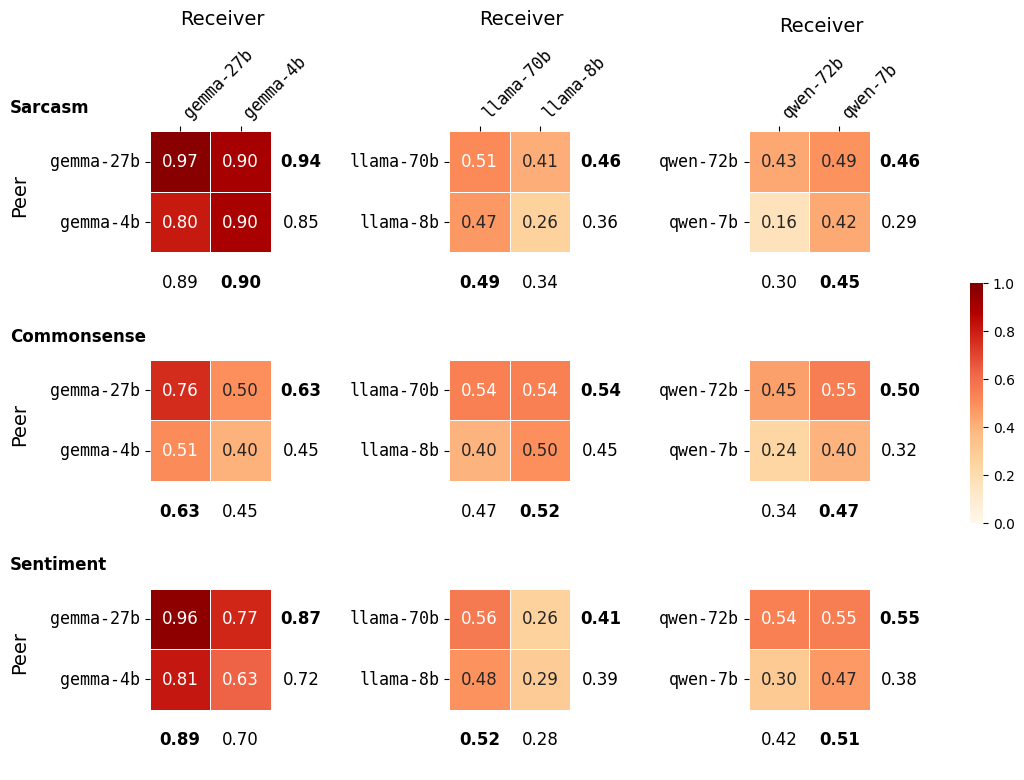

In [473]:
plot_main_results_pairs(DELTAS=DELTAS, value_col='macro_pos_delta_realisation')

plt.savefig("../plots/pairs-pos-overall.png", dpi=300, bbox_inches="tight")
plt.show()

#### Negative

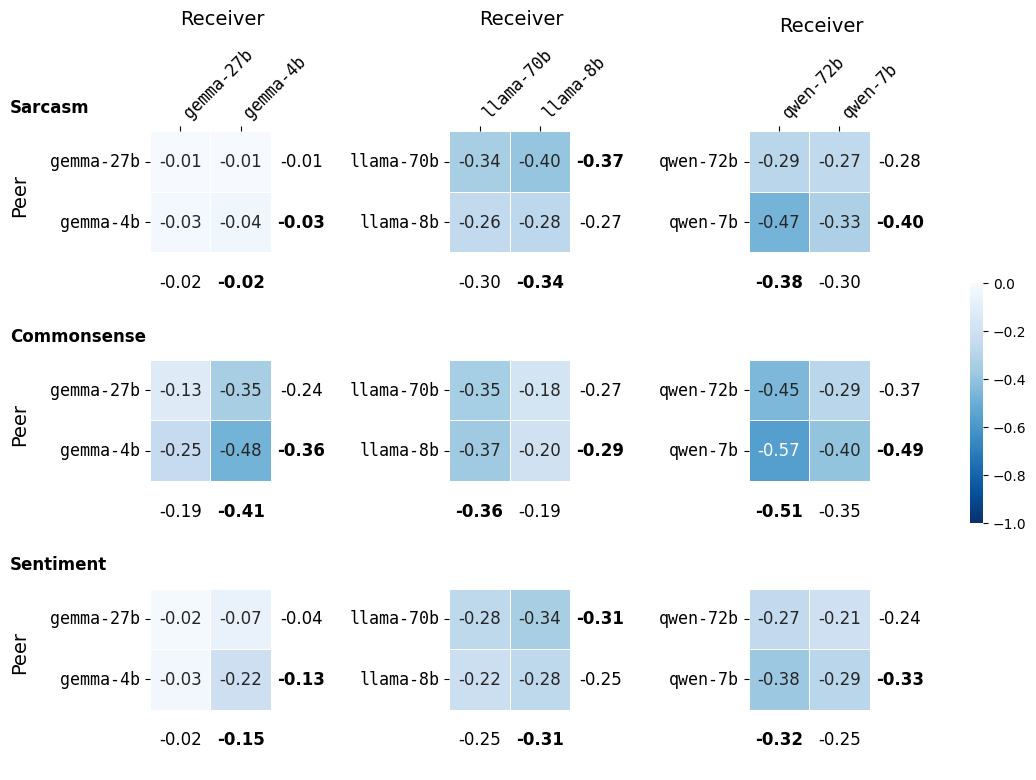

In [474]:
CMAP   = "Blues_r"
VMIN   = -1.0
VMAX   = 0.0

plot_main_results_pairs(DELTAS=DELTAS, value_col='macro_neg_delta_realisation')

plt.savefig("../plots/pairs-neg-overall.png", dpi=300, bbox_inches="tight")
plt.show()

## Scatterplots Influence Scores, Heterogeneous vs. Homogeneous

In [475]:
DATASET_NAMES = ['sarcasm', 'commonsense', 'sentiment']
large_deltas_dfs = {ds: DELTAS[ds]['disagreeing']['model'] for ds in DATASET_NAMES}

**Coloured by receiver**

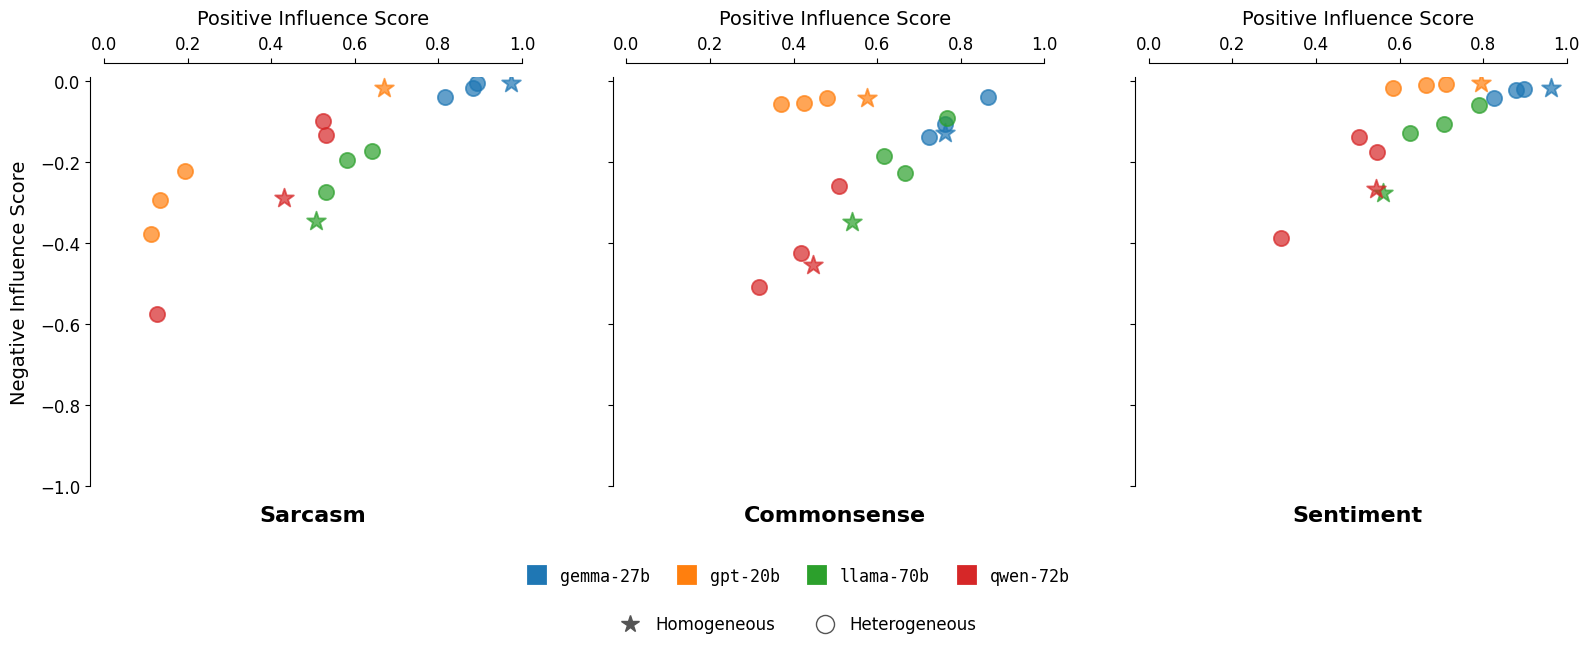

In [476]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor("#ffffff")

all_models = sorted(set(LARGE_MODELS))
 
palette = sns.color_palette("tab10", len(all_models))
color_map = dict(zip(all_models, palette))

SAME_MARKER = "*"
DIFF_MARKER = "o"
for ax, dataset in zip(axes, DATASET_NAMES):
    df = large_deltas_dfs[dataset]
    df = df[(df['model_sender'].isin(LARGE_MODELS)) & (df['model_receiver'].isin(LARGE_MODELS))]

    for _, row in df.iterrows():
        sender   = row["model_sender"]
        receiver = row["model_receiver"]
        x = row["macro_pos_delta_realisation"]
        y = row["macro_neg_delta_realisation"]
        same = sender == receiver

        ax.scatter(
            x, y,
            color=color_map[receiver], #if same else "#ffffff",
            marker=SAME_MARKER if same else DIFF_MARKER,
            s=200 if same else 120,
            edgecolors= color_map[receiver],
            linewidths=1.3,
            zorder=3,
            alpha=0.7,
        )

    ax.set_xlim(0, 1)
    ax.set_ylim(-1, 0.01)
    ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticks([-1,-0.8, -0.6, -0.4, -0.2, 0.0])
    
    ax.tick_params(labelsize=12)
    ax.xaxis.set_label_position('top')
    ax.set_xlabel("Positive Influence Score", fontsize=14, labelpad=8)
    ax.set_title(dataset.capitalize(), fontweight='bold', fontsize=16, pad=10, y=-0.12)
    sns.despine(ax=ax, bottom=True, right=True, top=False, offset=10)

    # Only show ylabel on leftmost plot
    if ax == axes[0]:
        ax.set_ylabel("Negative Influence Score", fontsize=14, labelpad=8)
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)

legend_handles = []
for m in sorted(color_map):
    legend_handles.append(
        Line2D([0], [0], marker='s', color='w',
               markerfacecolor=color_map[m], markeredgecolor=color_map[m],
               markeredgewidth=1.3, markersize=13, label=m)
    )
system_handles = []
system_handles.append(
    Line2D([0], [0], marker=SAME_MARKER, color='w',
           markerfacecolor='#555555', markeredgecolor='#555555',
           markeredgewidth=1, markersize=13, label='Homogeneous')
)
system_handles.append(
    Line2D([0], [0], marker=DIFF_MARKER, color='w',
           markerfacecolor='#ffffff', markeredgecolor='#555555',
           markeredgewidth=1, markersize=13, label='Heterogeneous')
)

fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.01),
    ncol=4,
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.4,
    prop={'family': 'monospace', 'size': 12},
)
fig.legend(
    handles=system_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.09),
    ncols = 2,
    frameon=False,
    fontsize=12,
    handletextpad=0.5,
)
plt.tight_layout()
plt.subplots_adjust(bottom=0.18, wspace=0.25)
plt.savefig('../plots/homo-vs-hetero.png', dpi=300, bbox_inches="tight")

**Coloured by peer**

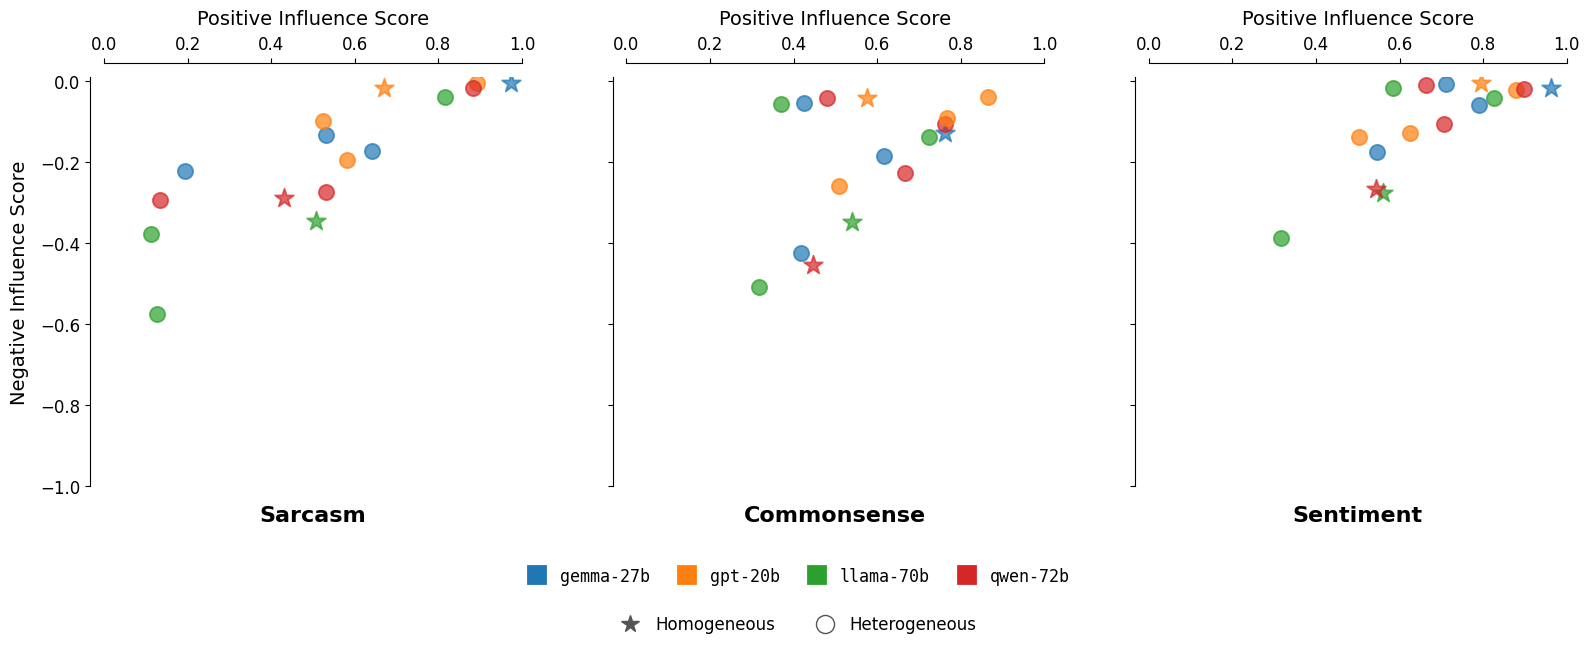

In [477]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor("#ffffff")

all_models = sorted(set(LARGE_MODELS))
 
palette = sns.color_palette("tab10", len(all_models))
color_map = dict(zip(all_models, palette))

SAME_MARKER = "*"
DIFF_MARKER = "o"
for ax, dataset in zip(axes, DATASET_NAMES):
    df = large_deltas_dfs[dataset]
    df = df[(df['model_sender'].isin(LARGE_MODELS)) & (df['model_receiver'].isin(LARGE_MODELS))]

    for _, row in df.iterrows():
        sender   = row["model_sender"]
        receiver = row["model_receiver"]
        x = row["macro_pos_delta_realisation"]
        y = row["macro_neg_delta_realisation"]
        same = sender == receiver

        ax.scatter(
            x, y,
            color=color_map[sender], #if same else "#ffffff",
            marker=SAME_MARKER if same else DIFF_MARKER,
            s=200 if same else 120,
            edgecolors= color_map[sender],
            linewidths=1.3,
            zorder=3,
            alpha=0.7,
        )

    ax.set_xlim(0, 1)
    ax.set_ylim(-1, 0.01)
    ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticks([-1,-0.8, -0.6, -0.4, -0.2, 0.0])
    
    ax.tick_params(labelsize=12)
    ax.xaxis.set_label_position('top')
    ax.set_xlabel("Positive Influence Score", fontsize=14, labelpad=8)
    ax.set_title(dataset.capitalize(), fontweight='bold', fontsize=16, pad=10, y=-0.12)
    sns.despine(ax=ax, bottom=True, right=True, top=False, offset=10)

    # Only show ylabel on leftmost plot
    if ax == axes[0]:
        ax.set_ylabel("Negative Influence Score", fontsize=14, labelpad=8)
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)

legend_handles = []
for m in sorted(color_map):
    legend_handles.append(
        Line2D([0], [0], marker='s', color='w',
               markerfacecolor=color_map[m], markeredgecolor=color_map[m],
               markeredgewidth=1.3, markersize=13, label=m)
    )
system_handles = []
system_handles.append(
    Line2D([0], [0], marker=SAME_MARKER, color='w',
           markerfacecolor='#555555', markeredgecolor='#555555',
           markeredgewidth=1, markersize=13, label='Homogeneous')
)
system_handles.append(
    Line2D([0], [0], marker=DIFF_MARKER, color='w',
           markerfacecolor='#ffffff', markeredgecolor='#555555',
           markeredgewidth=1, markersize=13, label='Heterogeneous')
)

fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.01),
    ncol=4,
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.4,
    prop={'family': 'monospace', 'size': 12},
)
fig.legend(
    handles=system_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.09),
    ncols = 2,
    frameon=False,
    fontsize=12,
    handletextpad=0.5,
)
plt.tight_layout()
plt.subplots_adjust(bottom=0.18, wspace=0.25)
plt.savefig('../plots/homo-vs-hetero-peer-based.png', dpi=300, bbox_inches="tight")

## Influence per Match Type Full Table (appendix)

Helpers

In [478]:
def fmt_delta(val) -> str:
    '''Format a delta value, returning '--' for NaN.'''
    if pd.isna(val):
        return "--"
    return f"{val:.2f}"

def fmt_count(val) -> str:
    '''Format count with comma separator.'''
    return f"{int(val):,}"

def build_wide_table(datasets: dict[str, pd.DataFrame], caption: str = "", label: str = "tab:models") -> str:
    '''
    Build a LaTeX longtable where each dataset occupies a column group
    (Positive Delta | Negative Delta | Count), and rows are keyed by
    (Receiver <- Peer, Match Type).
    Returns: 
        Full LaTeX table as a string
    '''

    dataset_names = list(datasets.keys())
    n_datasets = len(dataset_names)

    all_keys = []
    seen = set()
    for name, df in datasets.items():
        for _, row in df.iterrows():
            key = (row["model_sender"], row["model_receiver"], row["match_type"])
            if key not in seen:
                all_keys.append(key)
                seen.add(key)

    lookups = {}
    for name, df in datasets.items():
        lookup = {}
        for _, row in df.iterrows():
            key = (row["model_sender"], row["model_receiver"], row["match_type"])
            lookup[key] = row
        lookups[name] = lookup

    dataset_col_spec = " c c r" * n_datasets     
    col_spec = f"l r{dataset_col_spec}"

    dataset_headers = []
    for i, name in enumerate(dataset_names):
        start_col = 3 + i * 3       
        end_col   = start_col + 2
        dataset_headers.append(
            rf"\multicolumn{{3}}{{c}}{{\textsc{{{name.capitalize()}}}}}"
        )
    top_header = (
        r"\multirow{2}{*}{\textsc{Receiver} $\boldsymbol{\leftarrow}$ \textsc{Peer}}"
        r" & \multirow{2}{*}{\textsc{Match Type}}"
        " & " + " & ".join(dataset_headers) + r" \\"
    )

    # Cmidrule lines (skip cols 1-2)
    cmidrules = []
    for i in range(n_datasets):
        start = 3 + i * 3
        end   = start + 2
        cmidrules.append(rf"\cmidrule(lr){{{start}-{end}}}")
    cmidrule_line = " ".join(cmidrules)

    sub_cols = [r"\small Pos. Delta & \small Neg. Delta & \small Count"] * n_datasets
    sub_header = r" & & " + " & ".join(sub_cols) + r" \\"

    ordered_pairs = []
    pair_seen = set()
    for (sender, receiver, _) in all_keys:
        if (sender, receiver) not in pair_seen:
            ordered_pairs.append((sender, receiver))
            pair_seen.add((sender, receiver))


    body_lines = []

    for pair_idx, (sender, receiver) in enumerate(ordered_pairs):

        pair_keys = [k for k in all_keys if k[0] == sender and k[1] == receiver]

        s_label = rf"\texttt{{{sender}}}"
        r_label = rf"\texttt{{{receiver}}}"
        pair_str = rf"{r_label} $\leftarrow$ {s_label}"

        for key_idx, (s, r, mtype) in enumerate(pair_keys):

            data_cells = []
            for name in dataset_names:
                row = lookups[name].get((s, r, mtype))
                if row is not None:
                    pos = fmt_delta(row["positive_delta_realisation"])
                    neg = fmt_delta(row["negative_delta_realisation"])
                    cnt = fmt_count(row["count"])
                else:
                    pos, neg, cnt = "--", "--", "--"
                data_cells.append(f"{pos} & {neg} & {cnt}")

            row_label = pair_str if key_idx == 0 else ""
            body_lines.append(
                rf"{row_label} & {mtype} & " + " & ".join(data_cells) + r" \\"
            )


        if pair_idx < len(ordered_pairs) - 1:
            body_lines.append(r"\arrayrulecolor{Gray!80}\midrule")


    lines = []
    lines.append(r"\begin{center}")
    lines.append(r"\small")
    lines.append(rf"\begin{{longtable}}{{{col_spec}}}")
    lines.append(r"\toprule")
    lines.append(top_header)
    lines.append(cmidrule_line + r" \\")
    lines.append(sub_header)
    lines.append(r"\arrayrulecolor{Black!80}\midrule")
    lines.append(r"\endfirsthead")        
    lines.append(r"\toprule")
    lines.append(top_header)
    lines.append(cmidrule_line + r" \\")
    lines.append(sub_header)
    lines.append(r"\arrayrulecolor{Black!80}\midrule")
    lines.append(r"\endhead")
    lines.append(r"\midrule \multicolumn{" + str(2 + n_datasets * 3) + r"}{r}{\small\itshape continued\ldots} \\")
    lines.append(r"\endfoot")
    lines.append(r"\bottomrule")
    lines.append(rf"\caption{{\textbf{{{caption}}}}}")
    lines.append(rf"\label{{{label}}}")
    lines.append(r"\endlastfoot")
    lines.extend(body_lines)
    lines.append(r"\end{longtable}")
    lines.append(r"\end{center}")

    return "\n".join(lines)

In [479]:
datasets = {
    dataset: pd.concat([
        DELTAS[dataset]['disagreeing']['match_type'],
        DELTAS[dataset]['agreeing']['match_type']
    ]).sort_values(['model_sender', 'model_receiver', 'match_type']).reset_index(drop=True)
    for dataset in ['sarcasm', 'commonsense', 'sentiment']
}

In [480]:
print(build_wide_table(datasets=datasets, caption="hhhh", label="tab:large"))

\begin{center}
\small
\begin{longtable}{l r c c r c c r c c r}
\toprule
\multirow{2}{*}{\textsc{Receiver} $\boldsymbol{\leftarrow}$ \textsc{Peer}} & \multirow{2}{*}{\textsc{Match Type}} & \multicolumn{3}{c}{\textsc{Sarcasm}} & \multicolumn{3}{c}{\textsc{Commonsense}} & \multicolumn{3}{c}{\textsc{Sentiment}} \\
\cmidrule(lr){3-5} \cmidrule(lr){6-8} \cmidrule(lr){9-11} \\
 & & \small Pos. Delta & \small Neg. Delta & \small Count & \small Pos. Delta & \small Neg. Delta & \small Count & \small Pos. Delta & \small Neg. Delta & \small Count \\
\arrayrulecolor{Black!80}\midrule
\endfirsthead
\toprule
\multirow{2}{*}{\textsc{Receiver} $\boldsymbol{\leftarrow}$ \textsc{Peer}} & \multirow{2}{*}{\textsc{Match Type}} & \multicolumn{3}{c}{\textsc{Sarcasm}} & \multicolumn{3}{c}{\textsc{Commonsense}} & \multicolumn{3}{c}{\textsc{Sentiment}} \\
\cmidrule(lr){3-5} \cmidrule(lr){6-8} \cmidrule(lr){9-11} \\
 & & \small Pos. Delta & \small Neg. Delta & \small Count & \small Pos. Delta & \small Neg. Delta 

## Influence Heatmaps, Conditional Post-Interaction Certainty

In [481]:
def create_heat_matrix(df: pd.DataFrame, dataset_config: DatasetTaskSpec):
    deltas = df.copy()
    deltas['p_round1_receiver'] = np.where(
                deltas['label_sender_before'] == dataset_config.positive_label,
                deltas['p_pos'],
                deltas['p_neg']
            )


    x = deltas['p_round1_receiver'].round(1)
    y = deltas['p_round_2'].round(1)

    x_vals = np.round(np.arange(0.0, 1.0, 0.1), 1)
    y_vals = np.round(np.arange(0.0, 1.01, 0.1), 1)

    x_idx = {v: i for i, v in enumerate(x_vals)}
    y_idx = {v: i for i, v in enumerate(y_vals)}

    grid = np.zeros((len(y_vals), len(x_vals)), dtype=int)
    for xi, yi in zip(x, y):
        xi_r = round(float(xi), 1)
        yi_r = round(float(yi), 1)
        if xi_r in x_idx and yi_r in y_idx:
            grid[y_idx[yi_r], x_idx[xi_r]] += 1
        else:
            print('WARN: Out of range values.')
            print(xi_r, yi_r)


    col_sums = grid.sum(axis=0, keepdims=True)
    grid_cond = np.divide(grid, col_sums, out=np.zeros_like(grid, dtype=float), where=col_sums > 0)

    return grid_cond



In [482]:
def fmt(x):
    s = f"{x:.2f}"
    if x < 0:
        return "-" + s[1:].lstrip("0")
    
    if round(x, 2) == 0.00:
        return '0'
    
    if np.isnan(x):
        return '-' 
       
    return s.lstrip("0")

In [483]:
def parse_rgb(c):
    vals = c.strip('rgb()').split(',')
    return tuple(int(v) / 255 for v in vals)
colours = px.colors.sequential.tempo
CMAP = LinearSegmentedColormap.from_list(
    'ice_r',
    [parse_rgb(c) for c in colours]
)

In [484]:
def draw_heatmap_influence(ax, grid, show_cbar, cbar_ax):
    '''Plot heatmap'''
    annot = np.vectorize(fmt)(grid)
    nan_mask = np.isnan(grid)
    
    grid_filled = np.where(nan_mask, 0, grid)
    sns.heatmap(
        grid_filled,
        ax=ax,
        cmap=CMAP,
        vmin=VMIN,
        vmax=VMAX,
        annot=annot,
        fmt="",
        square=True,
        linewidths=0.05,
        cbar=show_cbar,
        cbar_ax=cbar_ax,
        cbar_kws={"shrink": 0.4} if show_cbar else {},
        annot_kws={'size': 12}
    )

In [485]:
def plot_heatmap_influence_large(df: pd.DataFrame, dataset: str, dataset_config: DatasetTaskSpec):
    '''
    Plots the influence heatmaps for the large models on specific dataset. 
    '''

    x_vals = np.round(np.arange(0.0, 1.0, 0.1), 1) 
    y_vals = np.round(np.arange(0.0, 1.01, 0.1), 1)
    xtick_labels = [f"{v:.1f}" for v in x_vals]
    ytick_labels = [f"{v:.1f}" for v in y_vals]
    
    n_rows, n_cols = len(ROW_ORDER), len(COL_ORDER)


    fig = plt.figure(figsize=(18, 18))
    cbar_ax = fig.add_axes([0.96, 0.40, 0.013, 0.25])
 

    grid = gridspec.GridSpec(
        n_rows, n_cols,
        figure=fig,
        hspace=0.05, # rows closer together 
        wspace= -0.05,
        left=0.12, 
        right=0.94,
        top=0.90, # more space below titles 
        bottom=0.08,
    )

    cbar_drawn = False

    for row_idx, sender in enumerate(ROW_ORDER):
        for col_idx, receiver in enumerate(COL_ORDER):
            ax = fig.add_subplot(grid[row_idx, col_idx])

            mask = (
                (df['model_sender'] == sender) &
                (df['model_receiver'] == receiver)
            )
            df_pair = df[mask]
            grid_values = create_heat_matrix(df_pair, dataset_config)

            if sender == receiver:
                grid_values[:, 0] = np.nan

            show_cbar = (not cbar_drawn)
            draw_heatmap_influence(
                ax, grid_values,
                show_cbar=show_cbar,
                cbar_ax=cbar_ax if show_cbar else None,
            )

            if show_cbar:
                cbar_drawn = True

            is_bottom = (row_idx == n_rows - 1)
            is_left = (col_idx == 0)

            ax.set_xlabel('$p_i^k(y\')$' if is_bottom else "", fontsize = 16, labelpad=15)
            ax.set_ylabel('$p_{i}^{k|j}(y\')$' if is_left else '', fontsize = 16, labelpad=15)


            if is_left:
                ax.annotate(
                    sender,
                    xy=(0, 0.5),
                    xycoords='axes fraction',
                    xytext=(-0.4, 0.5),
                    textcoords='axes fraction',
                    ha='center', va='center',
                    fontsize=16, fontweight='bold',
                    rotation=90,
                    family= 'monospace'
                )
                ax.set_yticks(np.arange(len(y_vals)) + 0.5)
                ax.set_yticklabels(ytick_labels, fontsize = 12)

            else:
                ax.set_yticklabels([])
                ax.yaxis.set_major_locator(plt.NullLocator())
                     
            if row_idx == 0:
                    ax.annotate(
                    receiver,
                    xy=(0.5, 1),
                    xycoords='axes fraction',
                    xytext=(0.5, 1.1),
                    textcoords='axes fraction',
                    ha='center', va='center',
                    fontsize=16, fontweight='bold',
                    family = 'monospace'
                )
               
            if is_bottom:
                ax.set_xticks(np.arange(len(x_vals)) + 0.5)
                ax.set_xticklabels(xtick_labels, fontsize = 12)
            else:
                ax.set_xticklabels([])
                ax.xaxis.set_major_locator(plt.NullLocator())
   
            ax.invert_yaxis()
            # Draw staircase diagonal
            heat_rows, heat_cols = grid_values.shape  # 11, 10
            xs, ys = [], []
            for col in range(heat_cols):
                row = col + 1 # inverted y axis
                xs += [col, col + 1]
                ys += [row, row]
            # connect steps vertically
            stair_x, stair_y = [xs[0]], [ys[0]]
            for i in range(1, len(xs)):
                if xs[i] == xs[i-1]:  # vertical step
                    stair_x.append(xs[i])
                    stair_y.append(ys[i])
                else:  # horizontal step
                    stair_x.append(xs[i])
                    stair_y.append(ys[i-1])
                    stair_x.append(xs[i])
                    stair_y.append(ys[i])

            ax.plot(stair_x, stair_y, color='#92374D', linewidth=1.5, linestyle='-', alpha = 0.9)
            
            heat_rows, heat_cols = grid_values.shape  # 11, 10
            xs, ys = [], []
            for col in range(heat_cols):
                row = col # inverted y axis
                xs += [col, col + 1]
                ys += [row, row]
            # connect steps vertically
            stair_x, stair_y = [xs[0]], [ys[0]]
            for i in range(1, len(xs)):
                if xs[i] == xs[i-1]:  # vertical step
                    stair_x.append(xs[i])
                    stair_y.append(ys[i])
                else:  # horizontal step
                    stair_x.append(xs[i])
                    stair_y.append(ys[i-1])
                    stair_x.append(xs[i])
                    stair_y.append(ys[i])

            ax.plot(stair_x, stair_y, color='#92374D', linewidth=1.5, linestyle='-', alpha = 0.9)

    fig.text(0.53, 0.94, "Receiver", ha='center', fontsize=20,)
    fig.text(0.03, 0.50, "Peer",   va='center', fontsize=20, rotation=90)

    plt.savefig(f'../plots/influence-{dataset}.png', dpi=300, bbox_inches = 'tight')
                

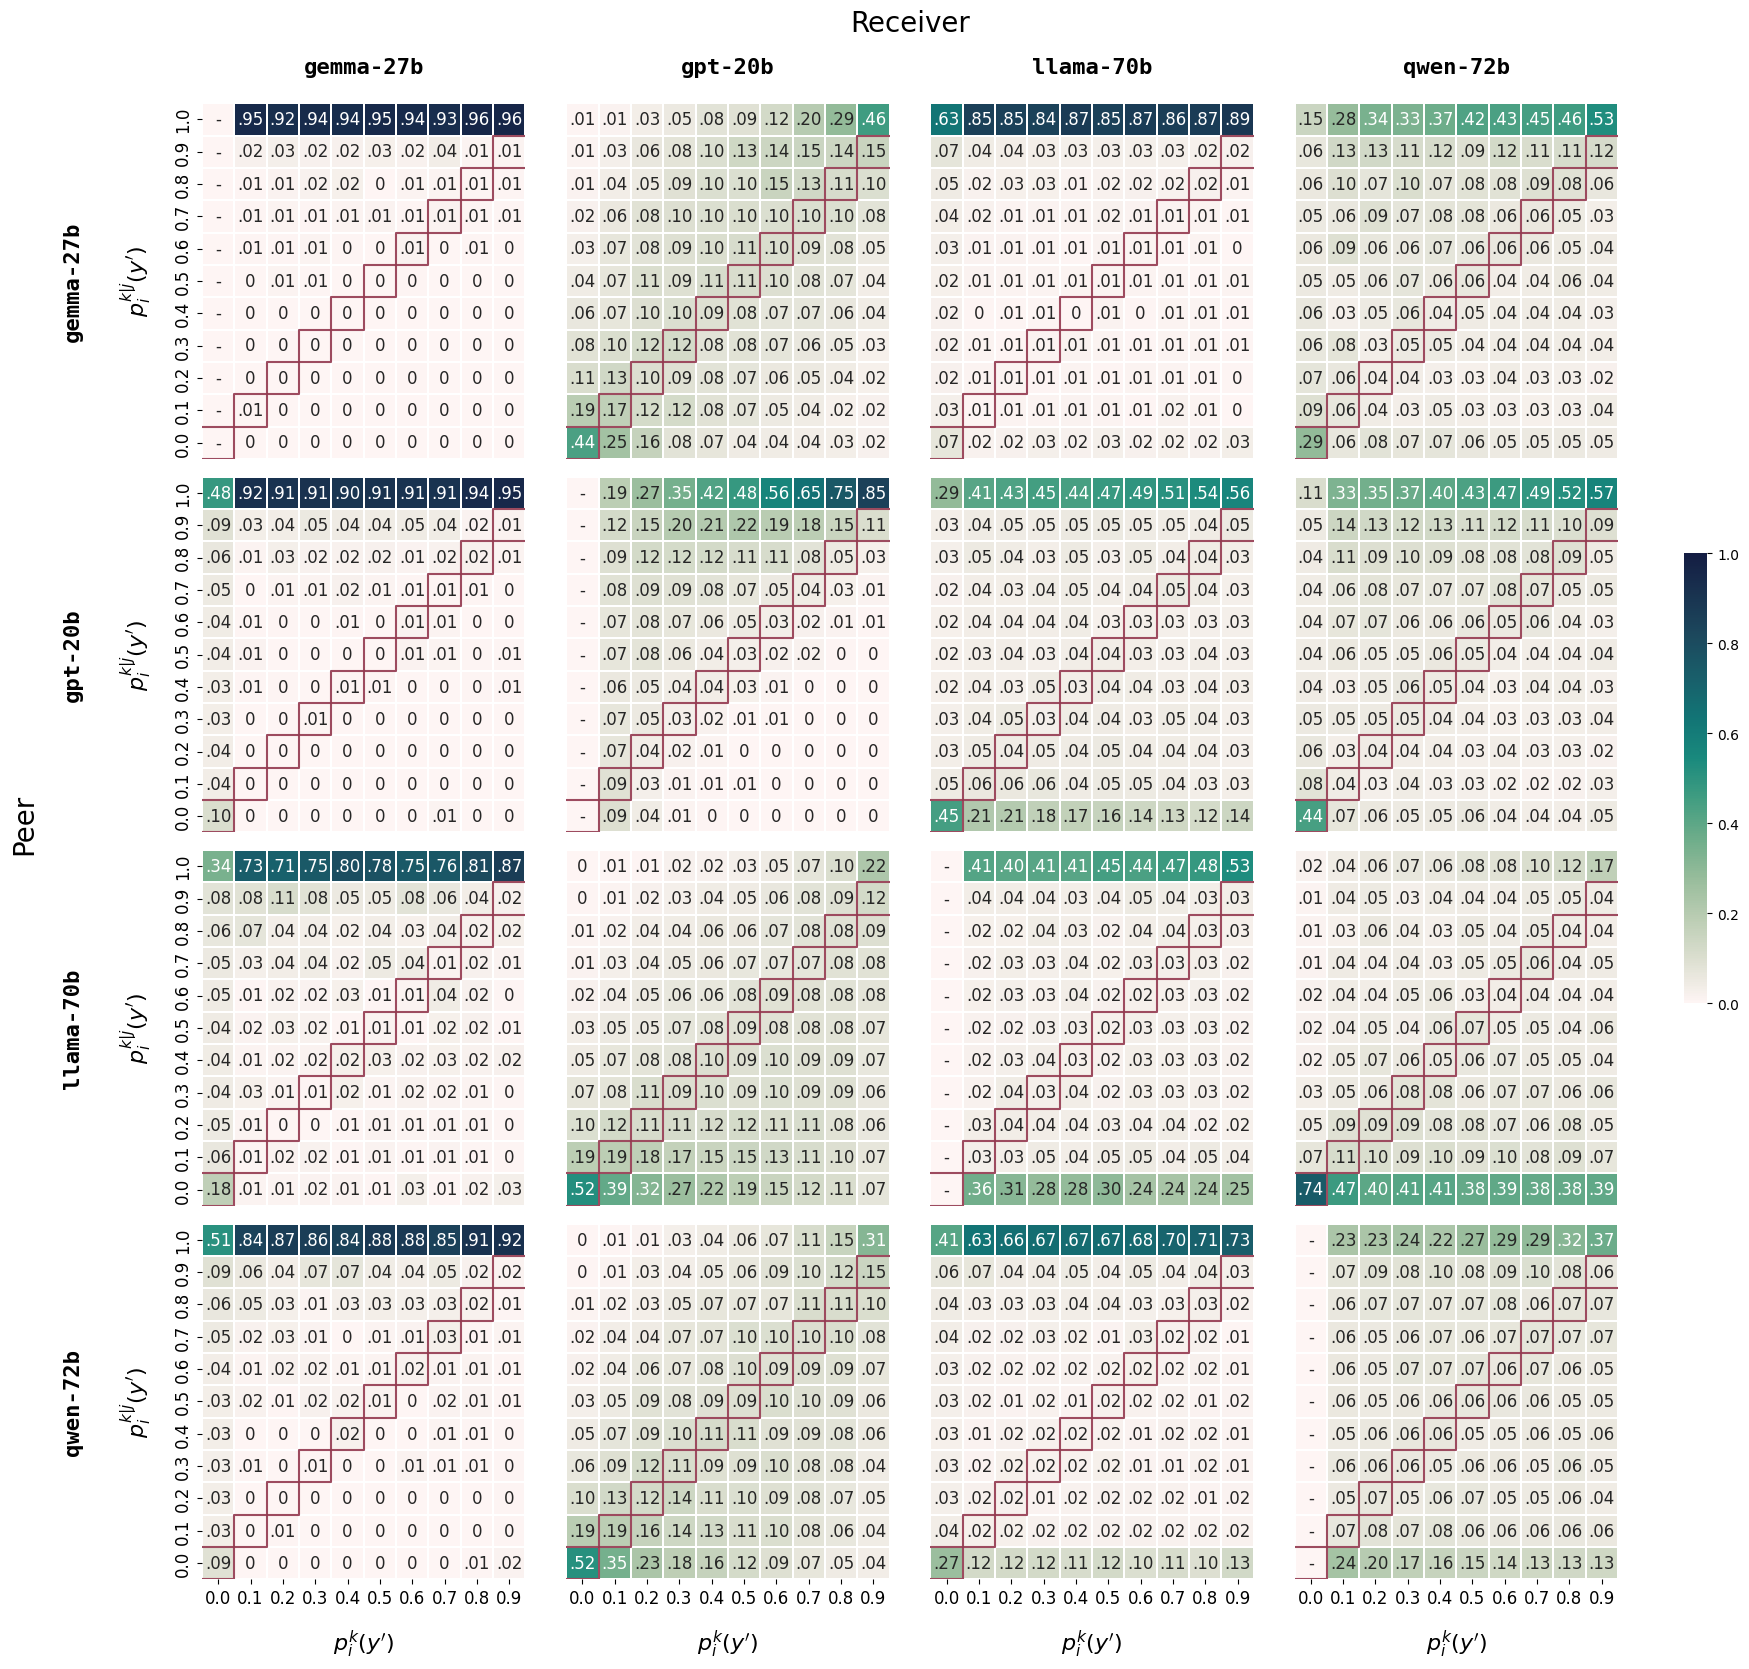

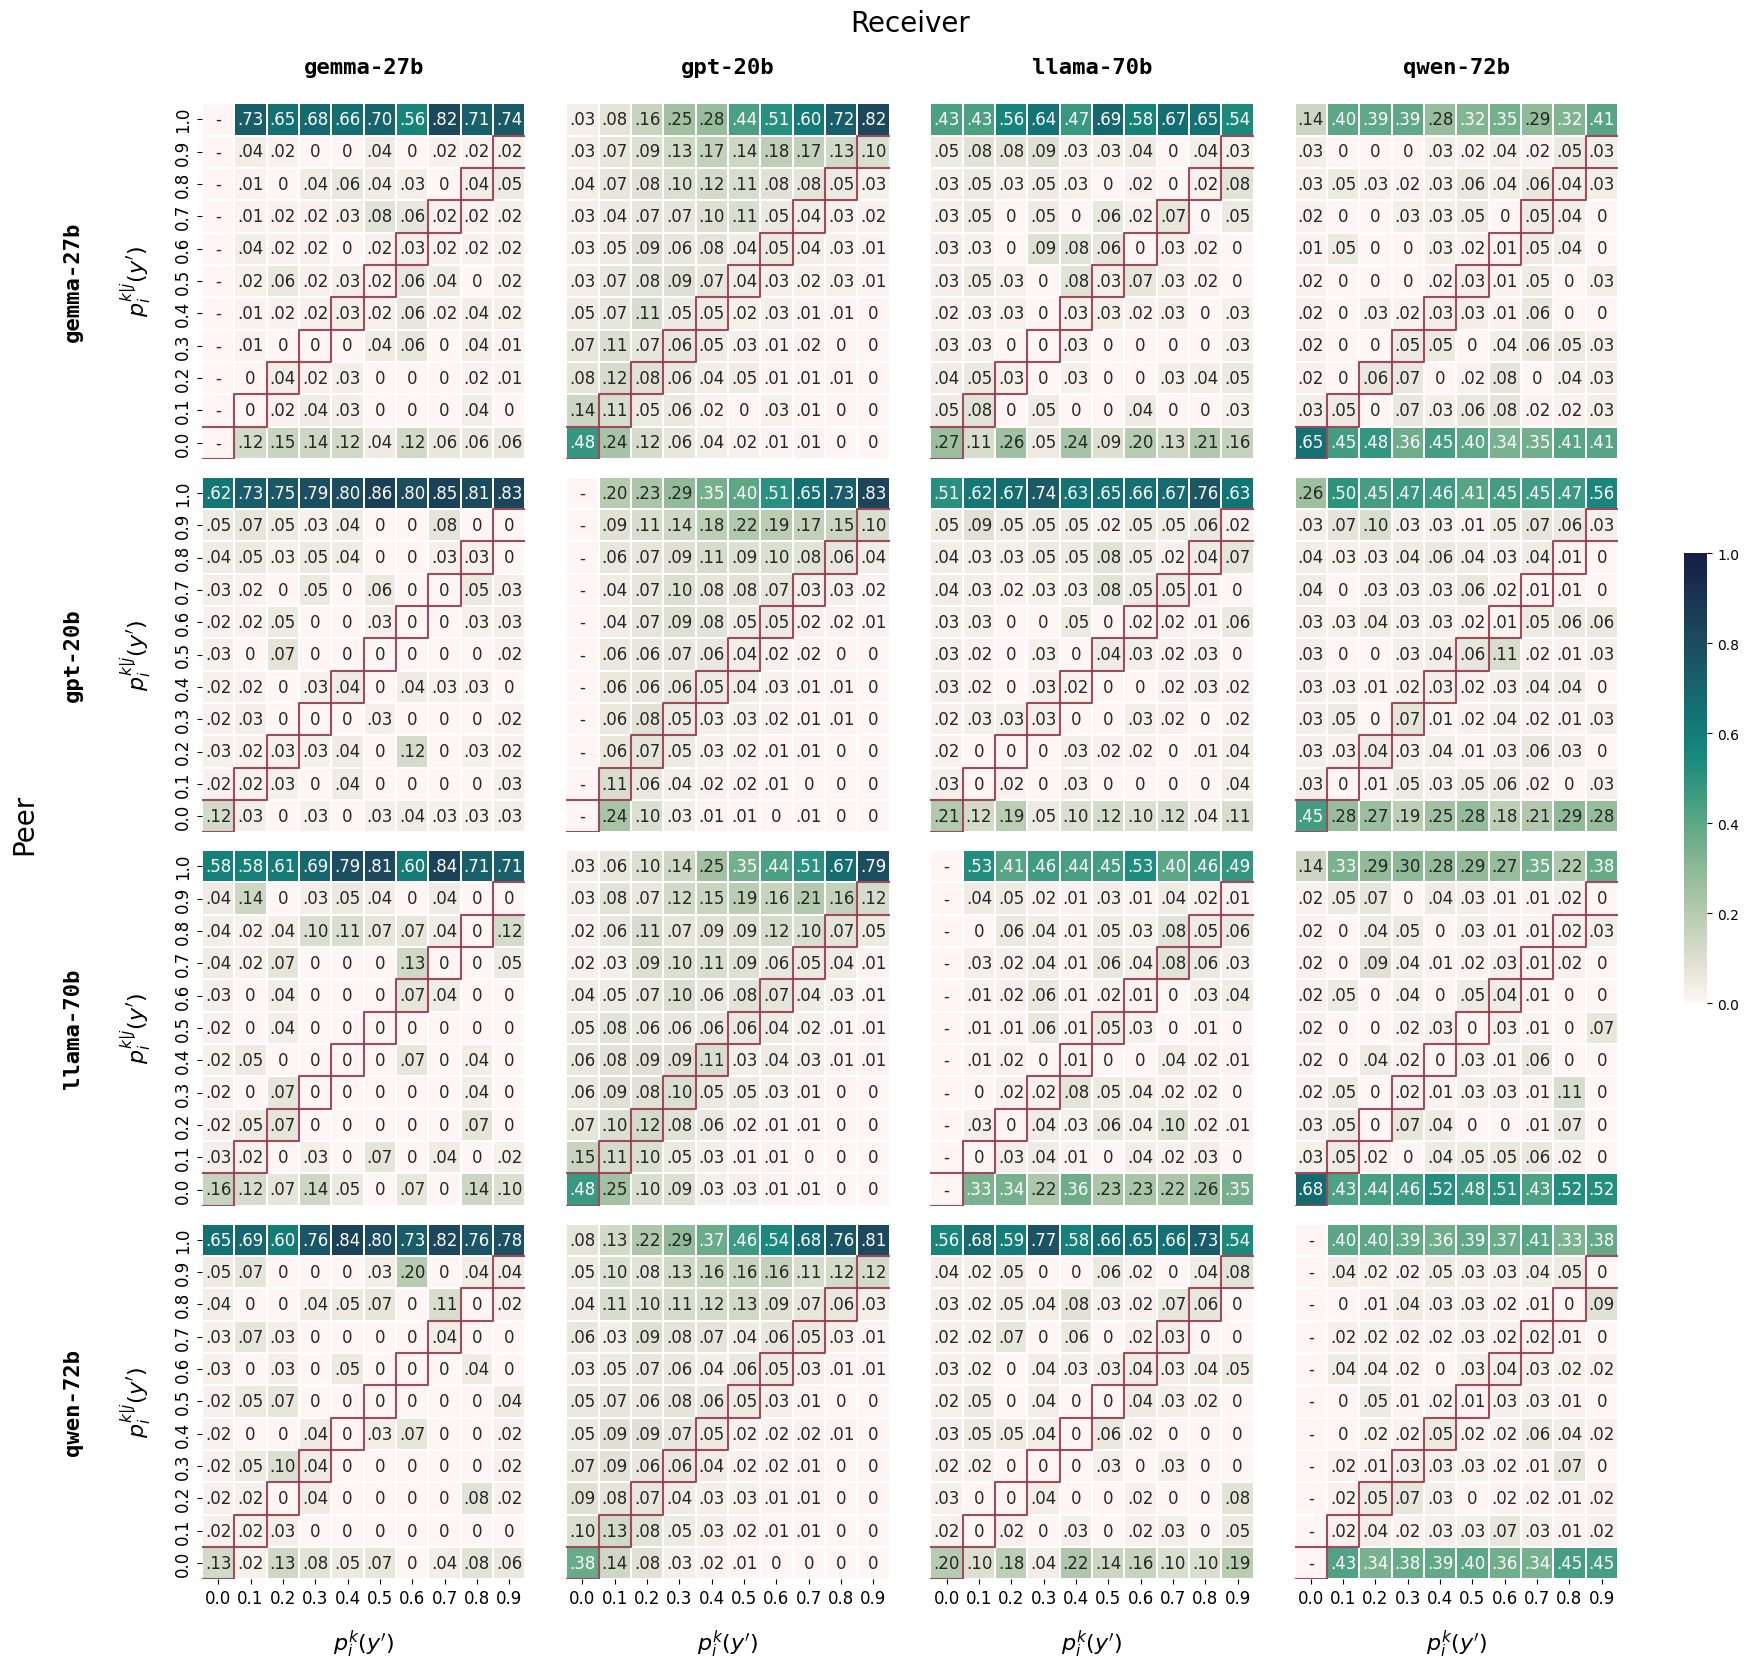

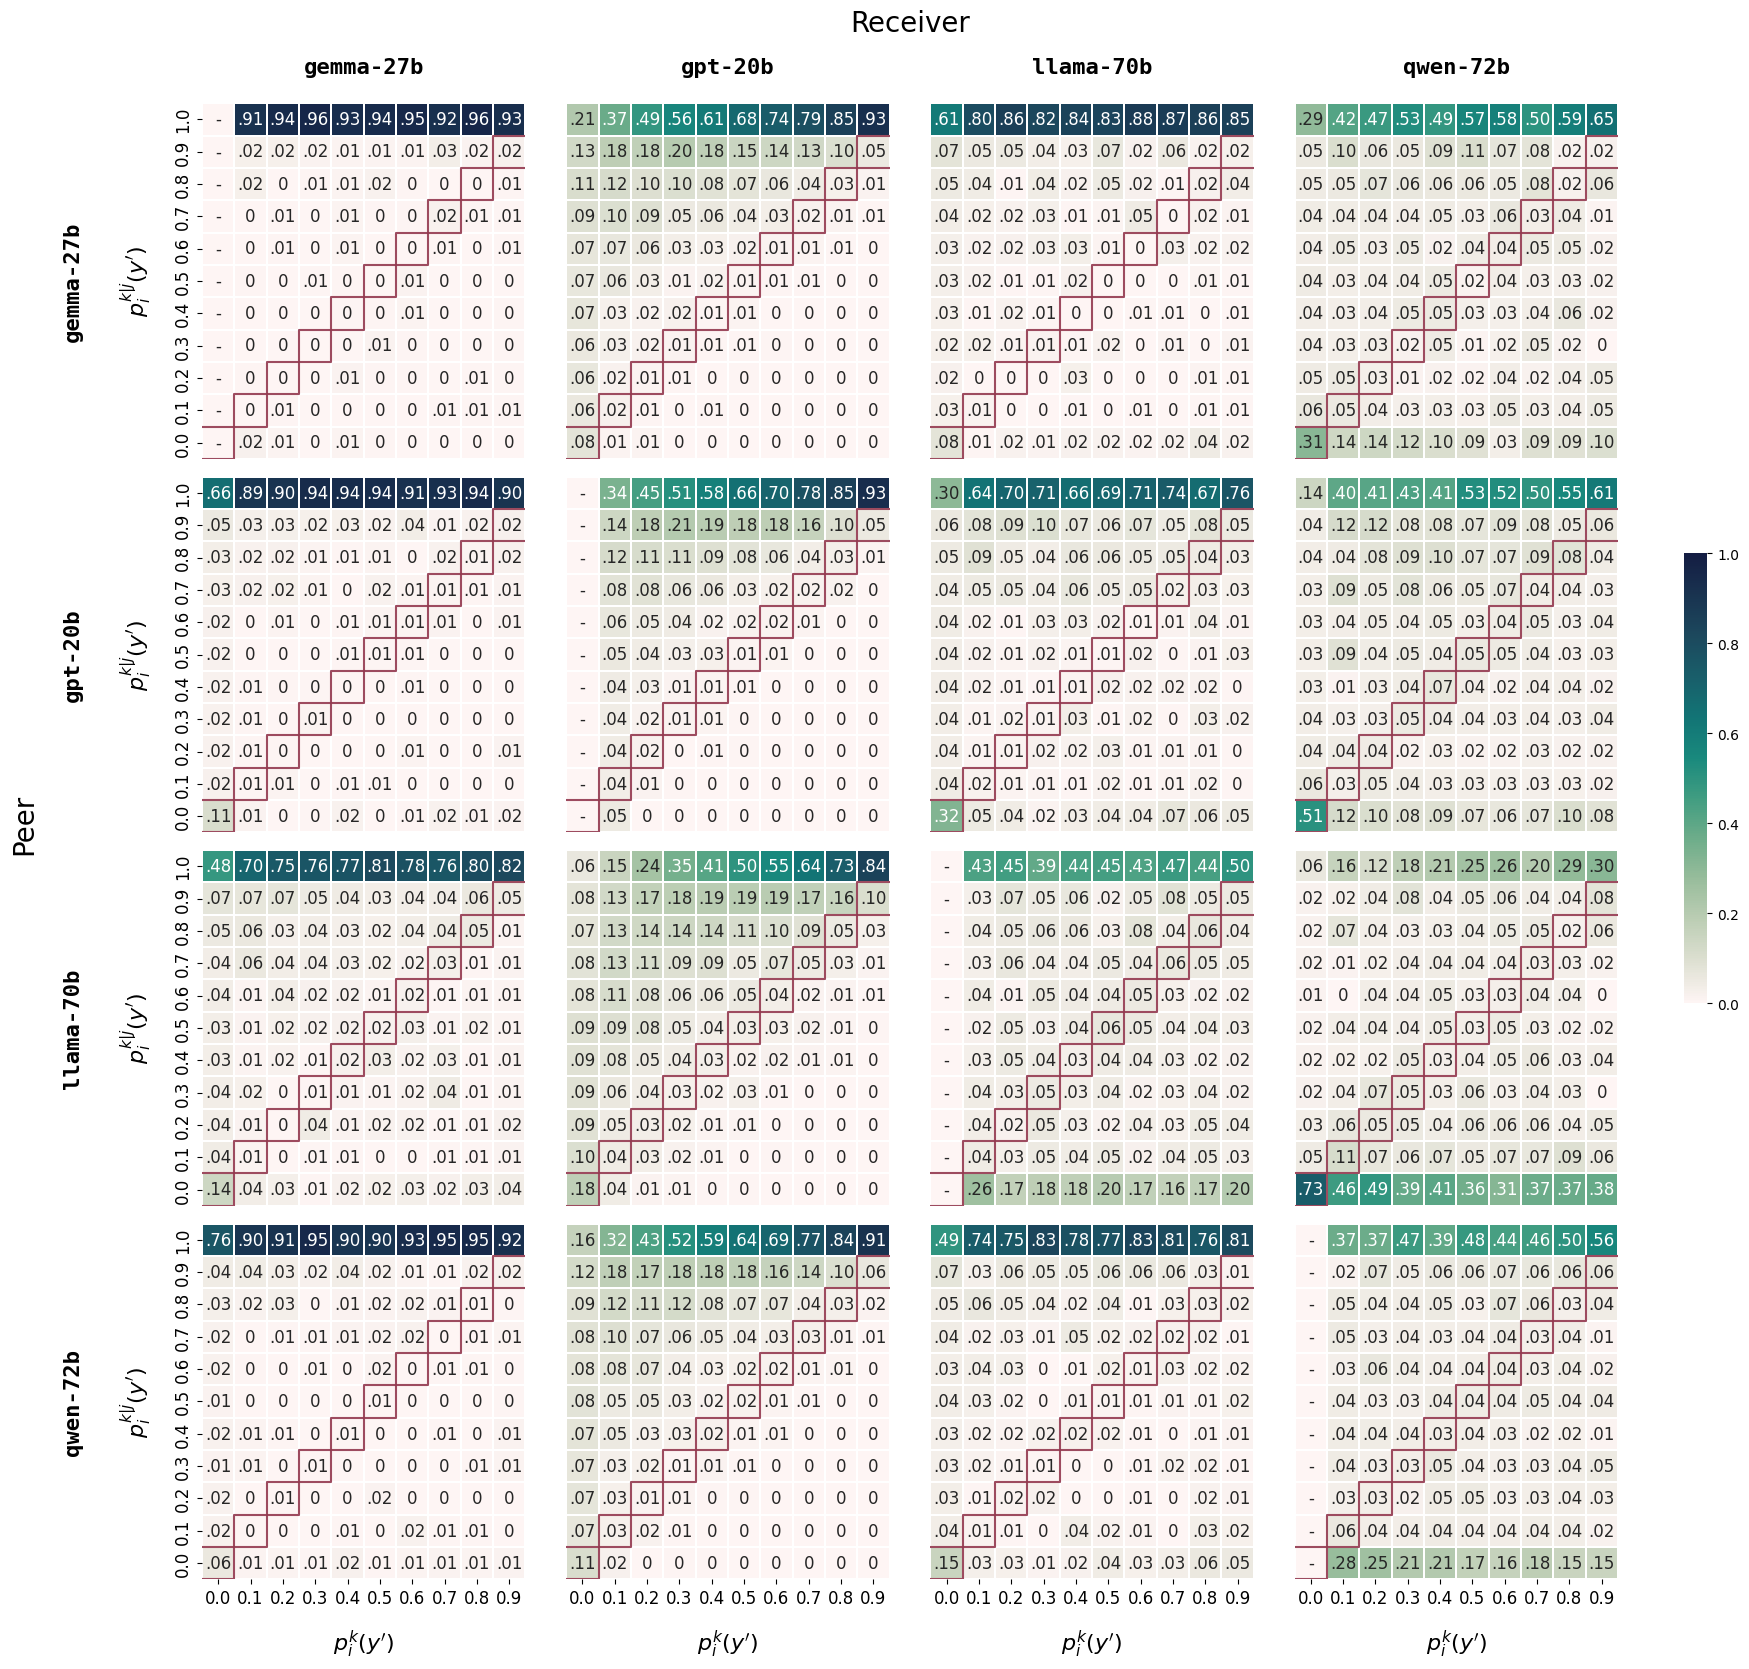

In [486]:
LARGE_MODELS = ['llama-70b','gemma-27b', 'qwen-72b', 'gpt-20b']

ROW_ORDER = sorted(LARGE_MODELS)
COL_ORDER = sorted(LARGE_MODELS)

VMIN = 0 
VMAX = 1
DATASET_NAMES = ['sarcasm', 'commonsense', 'sentiment'] #list(DELTAS.keys())

for data_name in DATASET_NAMES:
    data = DELTAS[data_name]['disagreeing']['all']
    plot_heatmap_influence_large(data, dataset=data_name, dataset_config=DATASETS[data_name])

## Influence Scores, Agreeing Configurations

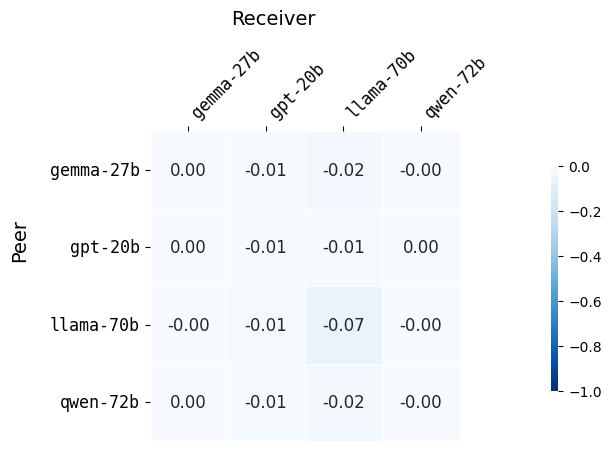

In [487]:
CMAP   = "Blues_r"
VMIN   = -1.0
VMAX   = 0.0

LARGE_MODELS = ['llama-70b','gemma-27b', 'qwen-72b', 'gpt-20b']

ROW_ORDER = sorted(LARGE_MODELS)
COL_ORDER = sorted(LARGE_MODELS)


fig = plt.figure(figsize=(6, 5))
 
grid = gridspec.GridSpec(
    1, 1,
    figure=fig,
    hspace=0.4, # rows closer together 
    wspace=0.1,
    left=0.1,
    right=0.88,
    top=0.7, # more space below titles 
    bottom=0.08,
)

# Shared colourbar axis (far right)
cbar_ax = fig.add_axes([0.9, 0.18, 0.013, 0.45])

cbar_drawn = False

ax = fig.add_subplot(grid[0])

agreeing = DELTAS['sarcasm']['agreeing']['model']
pivot = to_pivot(agreeing, 'macro_neg_delta_realisation', ROW_ORDER, COL_ORDER)

show_ylabel = True
show_cbar   = not cbar_drawn

draw_heatmap(
    ax, pivot,
    show_ylabel=show_ylabel,
    show_cbar=show_cbar,
    cbar_ax=cbar_ax if show_cbar else None,
    pos_delta=False
    
)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
if show_cbar:
    cbar_drawn = True

# ax.set_title('Sarcasm', fontweight = 'bold', fontsize = 14, pad = 10)

plt.savefig(f'../plots/large-neg-overall-agreeing.png', dpi=300, bbox_inches = 'tight')

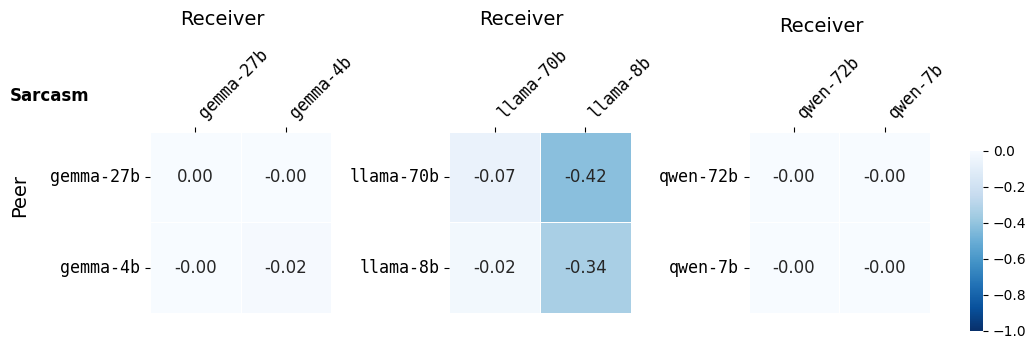

In [488]:
DATASET_NAMES = ['sarcasm']
value_col = 'macro_neg_delta_realisation'

PAIRS = [['gemma-27b','gemma-4b'], ['llama-70b','llama-8b'], ['qwen-72b', 'qwen-7b']]
ROW_ORDER = PAIRS
COL_ORDER = PAIRS
CMAP   = "Blues_r"
VMIN   = -1.0
VMAX   = 0.0

fig = plt.figure(figsize=(10, 12))

grid = gridspec.GridSpec(
    1, 3,
    figure=fig,
    hspace=0.45, # rows closer together 
    wspace=0.65,
    left=0.14, 
    right=0.92,
    top=0.90, # more space below titles 
    bottom=0.08,
)

cbar_ax = fig.add_axes([0.96, 0.40, 0.013, 0.15])

cbar_drawn = False

for row_idx, dataset in enumerate(DATASET_NAMES):
    df_model = DELTAS[dataset]['agreeing']['model'].copy()

    for col_idx, (m1, m2) in enumerate(PAIRS):
        ax = fig.add_subplot(grid[row_idx, col_idx])

        left_axes = (col_idx == 0)
        bottom_axes = (row_idx == 2)
        top_axes = (row_idx == 0)

        mask = (
        df_model['model_sender'].isin([m1, m2]) &
        df_model['model_receiver'].isin([m1, m2])
        )
        
        df_pair = df_model[mask]

        pivot = to_pivot(df_pair, value_col, ROW_ORDER[col_idx], COL_ORDER[col_idx])
        pivot = pivot.fillna(0)

        show_ylabel = True
        show_cbar   = (not cbar_drawn) and (row_idx==0) and (col_idx == 0)

        draw_heatmap(
            ax, pivot,
            show_ylabel=show_ylabel,
            show_cbar=show_cbar,
            cbar_ax=cbar_ax if show_cbar else None,
            pos_delta=False
        )
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
        if not top_axes:
            # If not the top axes then don't show xticks and labels 
            ax.xaxis.set_major_locator(plt.NullLocator())
            ax.set_xticklabels([])

        if not left_axes:
            ax.set_ylabel("")

        if show_cbar:
            cbar_drawn = True

        if left_axes:
            pos = ax.get_position()
            fig.text(
                0,                        
                pos.y0 + pos.height + 0.03,    
                f"{dataset.capitalize()}",
                ha="left", va="center",
                fontsize=12, fontweight="bold"
            )

plt.savefig(f'../plots/pairs-neg-overall-agreeing.png', dpi=300, bbox_inches = 'tight')


# Robustness results

In [489]:
BASE_PATH = Path('../evaluation')

def load_deltas_robustness(base_path: Path):
    deltas = defaultdict(lambda: defaultdict(dict))

    sarcasm_experiments_path = base_path / 'sarcasm'

    for dataset_dir in sarcasm_experiments_path.iterdir():
        if not dataset_dir.is_dir():
            continue
        type_experiment = dataset_dir

        for file in dataset_dir.glob('*.csv'):
            name = file.stem
            if name == 'claims_label_consistency':
                continue

            parts = name.split("_")

            agreement = parts[-1]

            if len(parts) == 2:
                agg = 'all'
            else:
                agg = '_'.join(parts[1:-1])

            df = pd.read_csv(file)
            
            df['model_sender'] = simplify_model_name(df['model_sender'])
            df['model_receiver'] = simplify_model_name(df['model_receiver'])
            
            deltas[type_experiment.name][agreement][agg] = df

    return deltas

In [490]:
DELTAS_ROBUSTNESS = load_deltas_robustness(BASE_PATH)
COL_ORDER_MAIN = ['model_receiver', 'model_sender', 'macro_pos_delta_realisation', 'macro_neg_delta_realisation']

COL_ORDER = ['model_receiver', 'model_sender', 
             'macro_pos_delta_realisation', 'pos_diff_from_main',
             'macro_neg_delta_realisation', 'neg_diff_from_main']


In [491]:
main_results = DELTAS['sarcasm']['disagreeing']['model']
main_results = main_results[(main_results['model_receiver'].isin(['gpt-20b', 'llama-70b', 'qwen-72b'])) & (main_results['model_sender'].isin(['gpt-20b', 'llama-70b', 'qwen-72b']))]

In [492]:
print(main_results[COL_ORDER_MAIN])

   model_receiver model_sender  macro_pos_delta_realisation  \
8         gpt-20b      gpt-20b                     0.670986   
9         gpt-20b    llama-70b                     0.112494   
10        gpt-20b     qwen-72b                     0.134784   
14      llama-70b      gpt-20b                     0.581391   
16      llama-70b    llama-70b                     0.508014   
17      llama-70b     qwen-72b                     0.532005   
19       qwen-72b      gpt-20b                     0.525099   
20       qwen-72b    llama-70b                     0.127180   
21       qwen-72b     qwen-72b                     0.429640   

    macro_neg_delta_realisation  
8                     -0.017914  
9                     -0.376252  
10                    -0.293038  
14                    -0.193962  
16                    -0.344614  
17                    -0.272895  
19                    -0.097621  
20                    -0.575537  
21                    -0.289582  


In [493]:
def add_delta_from_main(df: pd.DataFrame, main_df: pd.DataFrame) -> pd.DataFrame:
    """Add columns showing difference from main experiment results."""
    merged = df.merge(
        main_df[['model_receiver', 'model_sender', 'macro_pos_delta_realisation', 'macro_neg_delta_realisation']],
        on=['model_sender', 'model_receiver'],
        suffixes=('', '_main')
    )
    merged['pos_diff_from_main'] = merged['macro_pos_delta_realisation'] - merged['macro_pos_delta_realisation_main']
    merged['neg_diff_from_main'] = merged['macro_neg_delta_realisation'] - merged['macro_neg_delta_realisation_main']
    return merged.drop(columns=['macro_pos_delta_realisation_main', 'macro_neg_delta_realisation_main'])


## Swap

In [494]:
swap_disagreeing_model = DELTAS_ROBUSTNESS['swap']['disagreeing']['model']
swap_disagreeing_model = swap_disagreeing_model[swap_disagreeing_model['model_sender'].isin(['gpt-20b', 'llama-70b'])]
swap_disagreeing_model = add_delta_from_main(swap_disagreeing_model, main_results)


In [495]:
print(swap_disagreeing_model[COL_ORDER].to_latex(float_format="%.2f"))

\begin{tabular}{lllrrrr}
\toprule
 & model_receiver & model_sender & macro_pos_delta_realisation & pos_diff_from_main & macro_neg_delta_realisation & neg_diff_from_main \\
\midrule
0 & gpt-20b & llama-70b & 0.39 & 0.28 & -0.08 & 0.29 \\
1 & llama-70b & gpt-20b & 0.43 & -0.15 & -0.38 & -0.19 \\
\bottomrule
\end{tabular}



In [496]:
swap_disagreeing_mt = DELTAS_ROBUSTNESS['swap']['disagreeing']['match_type']
swap = swap_disagreeing_mt[['model_receiver', 'model_sender', 'match_type', 'positive_delta_realisation','negative_delta_realisation', 'count']]

swap = swap[swap['model_sender'].isin(['gpt-20b', 'llama-70b'])]
print(swap.sort_values(['model_receiver', 'match_type']))

   model_receiver model_sender match_type  positive_delta_realisation  \
7         gpt-20b    llama-70b        0:1                         NaN   
8         gpt-20b    llama-70b        0:B                    0.470867   
9         gpt-20b    llama-70b        1:0                         NaN   
10        gpt-20b    llama-70b        1:B                    0.243157   
11        gpt-20b    llama-70b        B:0                         NaN   
12        gpt-20b    llama-70b        B:1                         NaN   
13        gpt-20b    llama-70b        B:B                    0.466409   
21      llama-70b      gpt-20b        0:1                         NaN   
22      llama-70b      gpt-20b        0:B                    0.775634   
23      llama-70b      gpt-20b        1:0                         NaN   
24      llama-70b      gpt-20b        1:B                    0.076753   
25      llama-70b      gpt-20b        B:0                         NaN   
26      llama-70b      gpt-20b        B:1          

### Swap analysis

In [497]:
# For Llama as receiver

inp = pd.read_csv('../evaluation/qualitative_swap_analysis/llama-3.3-70b_disagree_swap.csv')
out = pd.read_csv('../evaluation/qualitative_swap_analysis/llama-3.3-70b-sarcasm.csv')
deltas = DELTAS['sarcasm']['disagreeing']['all']
deltas_main = deltas[(deltas['model_sender'] == 'gpt-20b') & (deltas['model_receiver'] == 'llama-70b')]
deltas = DELTAS_ROBUSTNESS['swap']['disagreeing']['all']
deltas_swap = deltas[(deltas['model_sender'] == 'gpt-20b') & (deltas['model_receiver'] == 'llama-70b')]

# # For gpt as receiver 
# inp = pd.read_csv('../gpt-oss-20b_disagree_swap.csv')
# out = pd.read_csv('../gpt-oss-20b-sarcasm.csv')
# deltas = DELTAS['sarcasm']['disagreeing']['all']
# deltas_main = deltas[(deltas['model_receiver'] == 'gpt-20b') & (deltas['model_sender'] == 'llama-70b')]
# deltas = DELTAS_ROBUSTNESS['swap']['disagreeing']['all']
# deltas_swap = deltas[(deltas['model_receiver'] == 'gpt-20b') & (deltas['model_sender'] == 'llama-70b')]

Let's categorise the claims into three categories:
- Increase in influence (swap_delta > main_delta):
  - Interpretation: An increase in influence would mean the receiver model values its own explanations higher than the other model's. 
- Decrease in influence (swap_delta < main_delta):
  - Interpretation: A decrease in influence would mean the receiver model values the peer's explanations higher than its own. 
- No difference in influence between experiments. 

In [498]:
df = deltas_main[['id', 'delta', 'match_type']].merge(
    deltas_swap[['id', 'delta', 'match_type']],
    on='id',
    suffixes=('_main', '_swap')
)

df['category_label'] = df.apply(
    lambda row: 'increase' if row['delta_swap'] > row['delta_main']
    else 'decrease' if row['delta_swap'] < row['delta_main']
    else 'no_difference',
    axis=1
)
df['magnitude'] = round(df['delta_swap'] - df['delta_main'], 2)

df = df.rename(columns={'match_type_main': 'main_match_type', 'match_type_swap': 'swap_match_type'})

In [499]:
df.groupby('category_label').agg(
    count = ('id', 'size'),
    mean_diff = ('magnitude', 'mean'),
    var_diff = ('magnitude', 'var')
).reset_index()

,category_label,count,mean_diff,var_diff
0,decrease,25833,-0.896586,0.407851
1,increase,8389,0.704184,0.232924
2,no_difference,15996,0.000000,0.000000


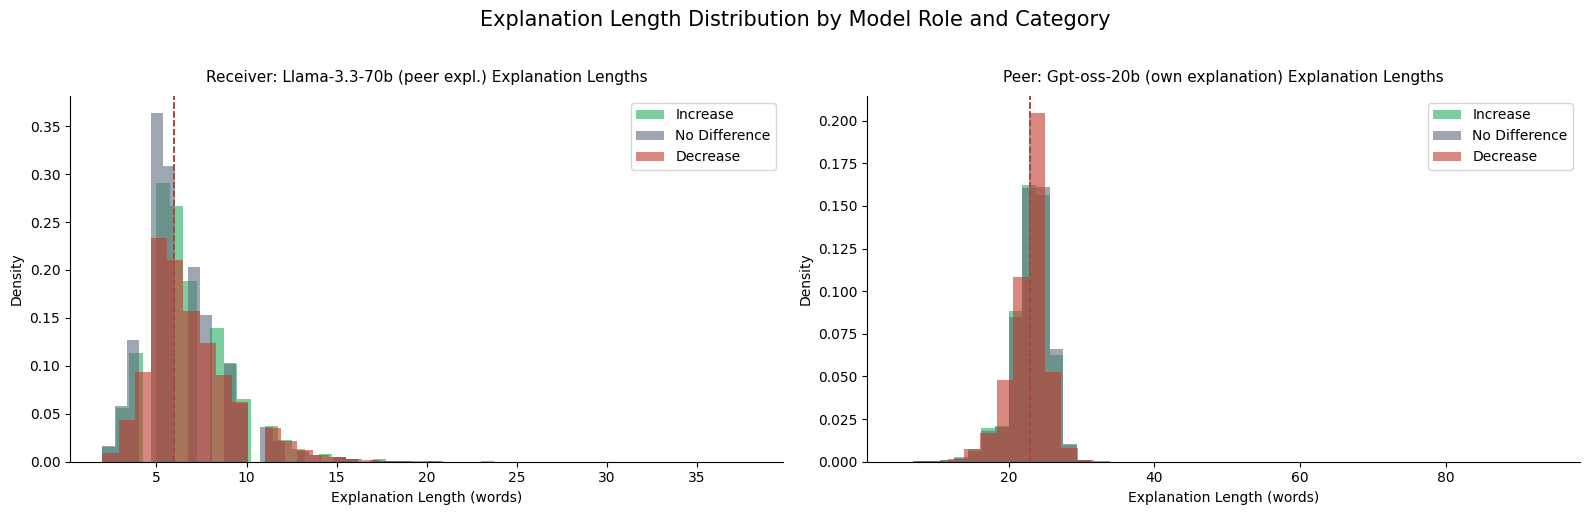

In [500]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

categories = ['increase', 'no_difference', 'decrease']
colors = {'increase': '#27ae60', 'no_difference': '#5d6d7e', 'decrease': '#c0392b'}

for ax, (col, title) in zip(axes, [('explanation_sender', f'Receiver: {inp['model_receiver'].iloc[0].capitalize()} (peer expl.)'), ('explanation_receiver', f'Peer: {inp['model_sender'].iloc[0].capitalize()} (own explanation)')]):
    for cat in categories:
        cat_ids = df[df['category_label'] == cat]['id']
        cat_inp = inp[inp['id'].isin(cat_ids)]
        lengths = cat_inp[col].str.split().str.len()
        
        ax.hist(lengths, bins=40, alpha=0.6,density = True, label=cat.replace('_', ' ').title(), color=colors[cat])
        ax.axvline(lengths.median(), color=colors[cat], linestyle='--', linewidth=1.2, alpha=0.9)

    ax.set_title(f'{title} Explanation Lengths', fontsize=11, pad=10)
    ax.set_xlabel('Explanation Length (words)')
    ax.set_ylabel('Density')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend()

plt.suptitle('Explanation Length Distribution by Model Role and Category', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [501]:
# Remember that explanation receiver will be the explanation that originates from the peer model. 
print(f'Average explanation length of peer model: {inp['model_sender'].iloc[0]}, that is framed as "you previously said":')
print(np.mean(inp['explanation_receiver'].str.split().str.len()))

print(f'Average explanation length of receiver model: {inp['model_receiver'].iloc[0]}, that is framed as "A peer of yours said":')
print(np.mean(inp['explanation_sender'].str.split().str.len()))

Average explanation length of peer model: gpt-oss-20b, that is framed as "you previously said":
22.874384692743345
Average explanation length of receiver model: llama-3.3-70b, that is framed as "A peer of yours said":
6.620324988090827


In [517]:
sampled_ids = (
    df[df['category_label'] != 'no_difference'].groupby('category_label')
      .apply(lambda x: x.sample(n=2))
      .reset_index()
)

In [518]:
for _, row in sampled_ids.iterrows():
    inp_rows = inp[inp['id'] == row['id']]
    out_rows = out[out['id'] == row['id']]
    
    explanations_html = ""
    for i, ((_, inp_row), (_, out_row)) in enumerate(zip(inp_rows.iterrows(), out_rows.iterrows())):
        explanations_html += f"""
        <div style="background:#2a2a2a; padding:6px 10px; border-radius:4px; margin-bottom:6px">
            <b style="color:#aaaaaa">Sample #{i+1}</b>
        </div>
        <div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin-bottom:12px">
            <div style="background:#1a2a3a; padding:10px; border-radius:6px; color:#c9dff0">
                <b>Peer Explanation ({inp_row['model_receiver']}):</b><br>{inp_row['explanation_sender']}
            </div>
            <div style="background:#2a2a1a; padding:10px; border-radius:6px; color:#e0d9b0">
                <b>Receiver Explanation ({inp_row['model_sender']}):</b><br>{inp_row['explanation_receiver']}
            </div>
        </div>
        <div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin-bottom:16px">
            <div style="color:#c9dff0"><b> </div>
            <div style="color:#e0d9b0"><b> </div>
        </div>
        """

    mag = row['magnitude']
    cat = row['category_label']
    color = '#27ae60' if cat == 'increase' else '#c0392b' if cat == 'decrease' else '#5d6d7e'

    html = f"""
    <div style="border:1px solid #444; border-radius:8px; padding:20px; margin:10px 0; font-family:sans-serif; max-width:800px; background:#1e1e1e; color:#dddddd">
        <div style="display:flex; justify-content:space-between; margin-bottom:15px; align-items:center">
            <span><b>ID:</b> {row['id']}</span>
            <span style="background:{color}; color:white; padding:3px 10px; border-radius:12px">{cat}</span>
            <span><b>Δ Main:</b> {row['delta_main']:+.4f}</span>
            <span><b>Δ Swap:</b> {row['delta_swap']:+.4f}</span>
            <span><b>Magnitude:</b> {mag:+.4f}</span>
        </div>
        <div style="background:#2a2a2a; padding:10px; border-radius:6px; margin-bottom:12px; color:#cccccc">
            <b>Claim:</b> {inp_rows.iloc[0]['claim']}
        </div>
        <div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin-bottom:16px; color:#bbbbbb">
            <div><b>Model Receiver:</b> {inp_rows.iloc[0]['model_receiver']}</div>
            <div><b>Model Peer:</b> {inp_rows.iloc[0]['model_sender']}</div>
        </div>
        <hr style="margin-bottom:16px; border-color:#444">
        {explanations_html}
    </div>
    """
    display(HTML(html))

## No History

In [504]:
no_history = DELTAS_ROBUSTNESS['no-history']['disagreeing']['model']
no_history = add_delta_from_main(no_history, main_results)
print(no_history[COL_ORDER].to_latex(float_format="%.2f"))



\begin{tabular}{lllrrrr}
\toprule
 & model_receiver & model_sender & macro_pos_delta_realisation & pos_diff_from_main & macro_neg_delta_realisation & neg_diff_from_main \\
\midrule
0 & llama-70b & qwen-72b & 0.53 & -0.00 & -0.23 & 0.05 \\
1 & qwen-72b & llama-70b & 0.76 & 0.64 & -0.03 & 0.54 \\
\bottomrule
\end{tabular}



## No Explanation

In [505]:
no_explanation = DELTAS_ROBUSTNESS['no-explanation']['disagreeing']['model']
no_explanation = add_delta_from_main(no_explanation, main_results)
print(no_explanation[COL_ORDER].to_latex(float_format="%.2f"))

\begin{tabular}{lllrrrr}
\toprule
 & model_receiver & model_sender & macro_pos_delta_realisation & pos_diff_from_main & macro_neg_delta_realisation & neg_diff_from_main \\
\midrule
0 & llama-70b & qwen-72b & 0.45 & -0.08 & -0.26 & 0.01 \\
1 & qwen-72b & llama-70b & 0.53 & 0.40 & -0.09 & 0.49 \\
\bottomrule
\end{tabular}



## Temperature

In [506]:
temperature = DELTAS_ROBUSTNESS['temperature']['disagreeing']['model']

In [507]:
print(temperature)

  model_receiver         model_sender  macro_pos_delta_realisation  \
0      llama-70b   qwen-72b-high-temp                     0.526745   
1      llama-70b    qwen-72b-low-temp                     0.524175   
2       qwen-72b  llama-70b-high-temp                     0.124887   
3       qwen-72b   llama-70b-low-temp                     0.125196   

   macro_neg_delta_realisation  count  
0                    -0.273176  11668  
1                    -0.289208   9536  
2                    -0.568099  12800  
3                    -0.574774   9031  


In [508]:
temperature['model_sender_display'] = temperature['model_sender']
temperature['model_sender'] = temperature['model_sender'].str.split('-').str[:2].str.join('-')

COL_ORDER = ['model_sender_display', 'model_receiver', 
             'macro_pos_delta_realisation', 'pos_diff_from_main',
             'macro_neg_delta_realisation', 'neg_diff_from_main']

In [509]:
temperature = add_delta_from_main(temperature, main_results)
print(temperature[COL_ORDER].to_latex(float_format="%.2f"))

\begin{tabular}{lllrrrr}
\toprule
 & model_sender_display & model_receiver & macro_pos_delta_realisation & pos_diff_from_main & macro_neg_delta_realisation & neg_diff_from_main \\
\midrule
0 & qwen-72b-high-temp & llama-70b & 0.53 & -0.01 & -0.27 & -0.00 \\
1 & qwen-72b-low-temp & llama-70b & 0.52 & -0.01 & -0.29 & -0.02 \\
2 & llama-70b-high-temp & qwen-72b & 0.12 & -0.00 & -0.57 & 0.01 \\
3 & llama-70b-low-temp & qwen-72b & 0.13 & -0.00 & -0.57 & 0.00 \\
\bottomrule
\end{tabular}



# Correlation, Label Consistency and Positive Influence

In [510]:
models = ['gemma-3-27b', 'gpt-oss-20b', 'llama-3.3-70b', 'qwen-2.5-72b']
models_abr = ['gemma-27b', 'gpt-20b', 'llama-70b', 'qwen-72b']

consistency, influence = [], []
for dataset in DATASETS.keys():
    # Consistency 
    consistency_df = pd.read_csv(f'../evaluation/{dataset}/main/claims_label_consistency.csv', index_col=0)
    consistency_df = consistency_df[consistency_df['model'].isin(models)]
    consistency_df.sort_values(by = 'model', inplace=True)
    total = consistency_df[['all_negative', 'all_positive', 'mixed']].sum(axis=1)
    consistency_df['consistent'] = 1 - (consistency_df['mixed'] / total)
    print(consistency_df[['model', 'consistent']])
    consistency.extend(consistency_df['consistent'].to_list())

    # Marginal influence score (receiver-level)
    deltas = DELTAS[dataset]['disagreeing']['model']
    deltas = deltas[(deltas['model_receiver'].isin(models_abr)) & (deltas['model_sender'].isin(models_abr))]
    deltas_average = deltas.groupby('model_receiver').agg(avg = ('macro_pos_delta_realisation', 'mean')).reset_index()
    deltas_average.sort_values(by = 'model_receiver', inplace=True)

    print(deltas_average)
    influence.extend(deltas_average['avg'].to_list())

           model  consistent
0    gemma-3-27b    0.979469
2    gpt-oss-20b    0.419144
4  llama-3.3-70b    0.925043
5   qwen-2.5-72b    0.949500
  model_receiver       avg
0      gemma-27b  0.891174
1        gpt-20b  0.277989
2      llama-70b  0.565833
3       qwen-72b  0.403444
           model  consistent
0    gemma-3-27b    0.985493
2    gpt-oss-20b    0.836849
4  llama-3.3-70b    0.985637
5   qwen-2.5-72b    0.982656
  model_receiver       avg
0      gemma-27b  0.891665
1        gpt-20b  0.688555
2      llama-70b  0.670053
3       qwen-72b  0.477522
           model  consistent
0    gemma-3-27b    0.973983
2    gpt-oss-20b    0.642703
4  llama-3.3-70b    0.965737
5   qwen-2.5-72b    0.952283
  model_receiver       avg
0      gemma-27b  0.777981
1        gpt-20b  0.462266
2      llama-70b  0.647223
3       qwen-72b  0.423034


In [511]:
print(consistency)
print(influence)

[0.9794688977810113, 0.41914385903647766, 0.9250434694040872, 0.9495004620634955, 0.9854925886050482, 0.8368492018615981, 0.9856373429084381, 0.9826562567961377, 0.9739825110655296, 0.6427029360967185, 0.9657371379161263, 0.9522832775558674]
[0.8911744931059838, 0.2779890744568381, 0.5658331610495204, 0.40344371214950414, 0.8916650760935385, 0.6885550387731505, 0.6700533914626943, 0.47752232564142505, 0.7779807815723493, 0.46226620307154864, 0.6472230547787049, 0.42303387898609685]


In [512]:
res = stats.spearmanr(consistency, influence)
res.statistic

np.float64(0.6083916083916086)

In [513]:
res.pvalue

np.float64(0.035805997052029234)

In [514]:
def statistic(x): # permute only `x`
    return stats.spearmanr(x, consistency).statistic
res_exact = stats.permutation_test((influence,), statistic,
    permutation_type='pairings')
res_asymptotic = stats.spearmanr(consistency, influence)
res_exact.pvalue, res_asymptotic.pvalue # asymptotic pvalue is too low

(np.float64(0.0356), np.float64(0.035805997052029234))